# DYTurbo — Results analysis

Data extracted from `1D.root` and `2D.root` via `extract_grids.py`.

| File | Content |
|------|--------|
| `grids/dyturbo_1d.parquet` | 1D distributions in q_T — Z, Wp, Wm |
| `grids/dyturbo_2d_wp.parquet` | 2D grid (q_T × p_T^l) — W⁺ |
| `grids/dyturbo_2d_wm.parquet` | 2D grid (q_T × p_T^l) — W⁻ |
| `grids/dyturbo_proj_qt.parquet` | 2D→q_T projection (precomputed) — Wp, Wm |
| `grids/dyturbo_proj_ptl.parquet` | 2D→p_T^l projection (precomputed) — Wp, Wm |

Values are cross-sections **integrated over the bin** [fb].

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4g}'.format)

## 1 — Data loading

In [23]:
def drop_extreme_scales(df):
    """Remove scale variations with ratio equal to 4 or 1/4."""
    def bad(a, b):
        r = (df[a] / df[b]).round(6)
        return r.isin([4.0, 0.25])
    mask = bad('muR','muF') | bad('muR','muQ') | bad('muF','muQ')
    return df[~mask].reset_index(drop=True)

df1d    = drop_extreme_scales(pd.read_parquet('grids/dyturbo_1d.parquet'))
df2d_wp = drop_extreme_scales(pd.read_parquet('grids/dyturbo_2d_wp.parquet'))
df2d_wm = drop_extreme_scales(pd.read_parquet('grids/dyturbo_2d_wm.parquet'))
df_pqt  = drop_extreme_scales(pd.read_parquet('grids/dyturbo_proj_qt.parquet'))
df_pptl = drop_extreme_scales(pd.read_parquet('grids/dyturbo_proj_ptl.parquet'))

print('1D      :', df1d.shape)
print('2D Wp   :', df2d_wp.shape)
print('2D Wm   :', df2d_wm.shape)
print('proj_qt :', df_pqt.shape)
print('proj_ptl:', df_pptl.shape)


1D      : (4650, 10)
2D Wp   : (54250, 11)
2D Wm   : (54250, 11)
proj_qt : (3100, 10)
proj_ptl: (2170, 10)


In [24]:
# Panoramica 1D
display(df1d.groupby(['boson', 'order','muR','muF','muQ'], observed=True)['value'].size().reset_index(name='n_celle'))
display(df_pptl.groupby(['boson', 'order','muR','muF','muQ'], observed=True)['value'].size().reset_index(name='n_celle'))


,boson,order,muR,muF,muQ,n_celle
0,Wm,N3LL,1,1,1,50
1,Wm,NLL,0.5,0.5,0.5,50
2,Wm,NLL,0.5,0.5,1,50
3,Wm,NLL,0.5,1,0.5,50
4,Wm,NLL,0.5,1,1,50
...,...,...,...,...,...,...
88,Z,NNLL,1,2,2,50
89,Z,NNLL,2,1,1,50
90,Z,NNLL,2,1,2,50
91,Z,NNLL,2,2,1,50


,boson,order,muR,muF,muQ,n_celle
0,Wm,N3LL,1,1,1,35
1,Wm,NLL,0.5,0.5,0.5,35
2,Wm,NLL,0.5,0.5,1,35
3,Wm,NLL,0.5,1,0.5,35
4,Wm,NLL,0.5,1,1,35
...,...,...,...,...,...,...
57,Wp,NNLL,1,2,2,35
58,Wp,NNLL,2,1,1,35
59,Wp,NNLL,2,1,2,35
60,Wp,NNLL,2,2,1,35


In [25]:
# Available scale combinations after filtering
print('=== Wp ===')
display(df2d_wp.groupby(['order','muR','muF','muQ'], observed=True)
               .size().reset_index(name='n_celle'))
print('=== Wm ===')
display(df2d_wm.groupby(['order','muR','muF','muQ'], observed=True)
               .size().reset_index(name='n_celle'))


=== Wp ===


,order,muR,muF,muQ,n_celle
0,N3LL,1,1,1,1750
1,NLL,0.5,0.5,0.5,1750
2,NLL,0.5,0.5,1,1750
3,NLL,0.5,1,0.5,1750
4,NLL,0.5,1,1,1750
5,NLL,1,0.5,0.5,1750
6,NLL,1,0.5,1,1750
7,NLL,1,1,0.5,1750
8,NLL,1,1,1,1750
9,NLL,1,1,2,1750


=== Wm ===


,order,muR,muF,muQ,n_celle
0,N3LL,1,1,1,1750
1,NLL,0.5,0.5,0.5,1750
2,NLL,0.5,0.5,1,1750
3,NLL,0.5,1,0.5,1750
4,NLL,0.5,1,1,1750
5,NLL,1,0.5,0.5,1750
6,NLL,1,0.5,1,1750
7,NLL,1,1,0.5,1750
8,NLL,1,1,1,1750
9,NLL,1,1,2,1750


In [26]:
# Nominal selection (muF=muQ=muR=1.0)
nom1d = df1d.query('muF==1.0 and muQ==1.0 and muR==1.0')
nom1d.head(6)


,boson,order,muF,muQ,muR,qt_lo,qt_hi,qt_center,value,error
0,Wm,N3LL,1,1,1,0,2,1,1.057e+05,1.035e+04
1,Wm,N3LL,1,1,1,2,4,3,1.859e+05,4221
2,Wm,N3LL,1,1,1,4,6,5,1.965e+05,3415
3,Wm,N3LL,1,1,1,6,8,7,1.813e+05,2793
4,Wm,N3LL,1,1,1,8,10,9,1.556e+05,2072
5,Wm,N3LL,1,1,1,10,12,11,1.3e+05,3396


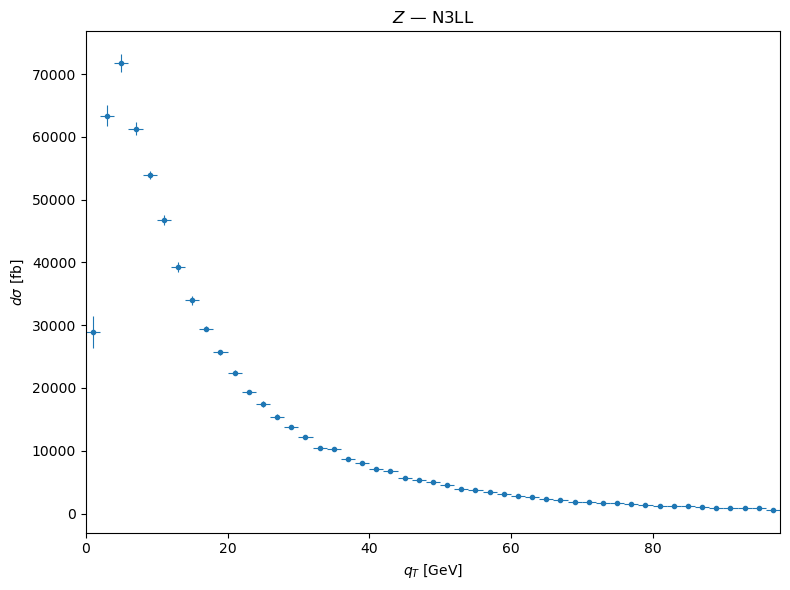

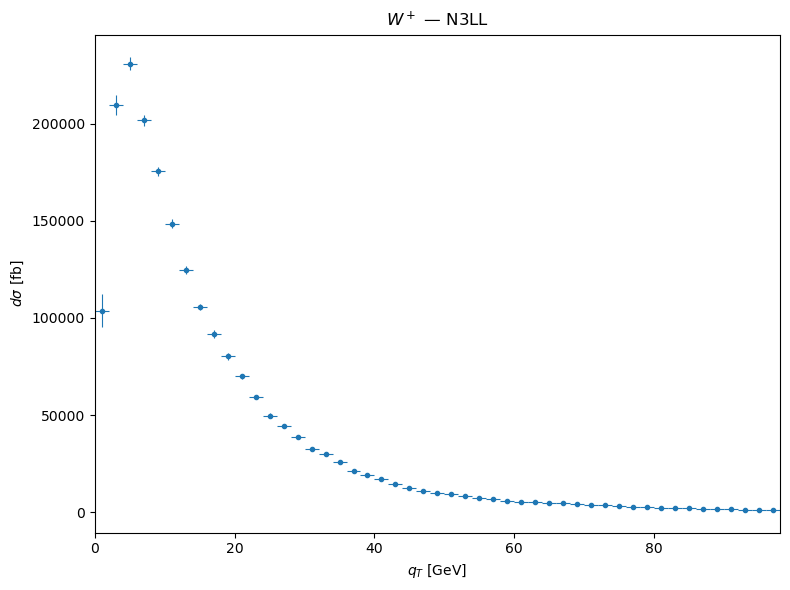

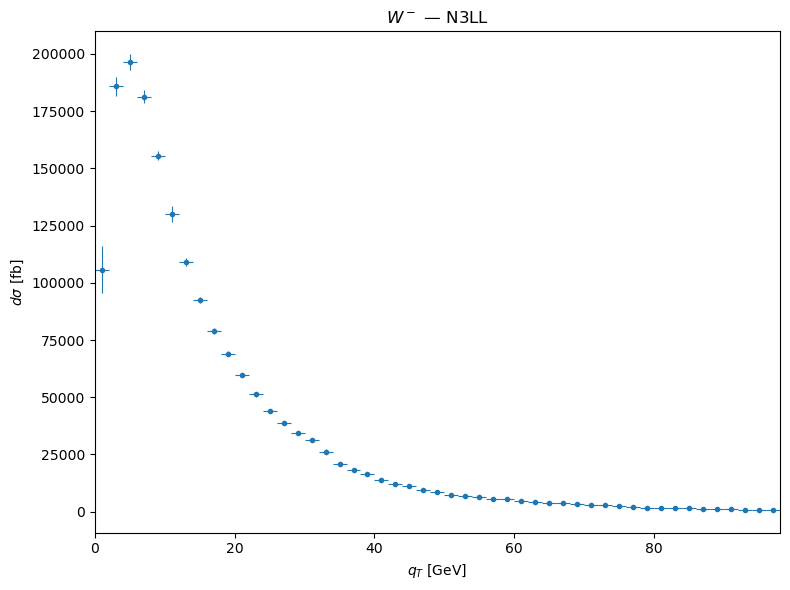

In [27]:
ORDER  = 'N3LL'   # ← 'NLL', 'NNLL', 'N3LL'
titles = {'Z': r'$Z$', 'Wp': r'$W^+$', 'Wm': r'$W^-$'}

nom = nom1d[nom1d['order'] == ORDER].copy()
nom = nom[nom['qt_hi'] < 100]

for boson in ['Z', 'Wp', 'Wm']:
    sub = nom[nom['boson'] == boson]
    w   = (sub['qt_hi'] - sub['qt_lo']).values
    fig, ax = plt.subplots(figsize=(8, 6))
    if ORDER == 'N3LL':
        ax.errorbar(
            sub['qt_center'], sub['value'],
            yerr=sub['error'], xerr=w/2,
            fmt='o', markersize=3, linewidth=0,
            elinewidth=0.8, capsize=0, color='C0'
        )
    else:
        up, lo = envelope(df1d, boson, ORDER)
        ax.bar(sub['qt_lo'].values, (up - lo).values, bottom=lo.values,
               width=w, align='edge', alpha=0.30, color='C0', linewidth=0)
        # ax.step(sub['qt_center'], sub['value'], where='mid', color='C0')
    ax.set_xlabel(r'$q_T$ [GeV]')
    ax.set_ylabel(r'$d\sigma$ [fb]')
    ax.set_title(f'{titles[boson]} — {ORDER}')
    ax.set_xlim(0, 98)
    plt.tight_layout()
    plt.show()


## 2 — 1D distribution in q_T: perturbative order comparison

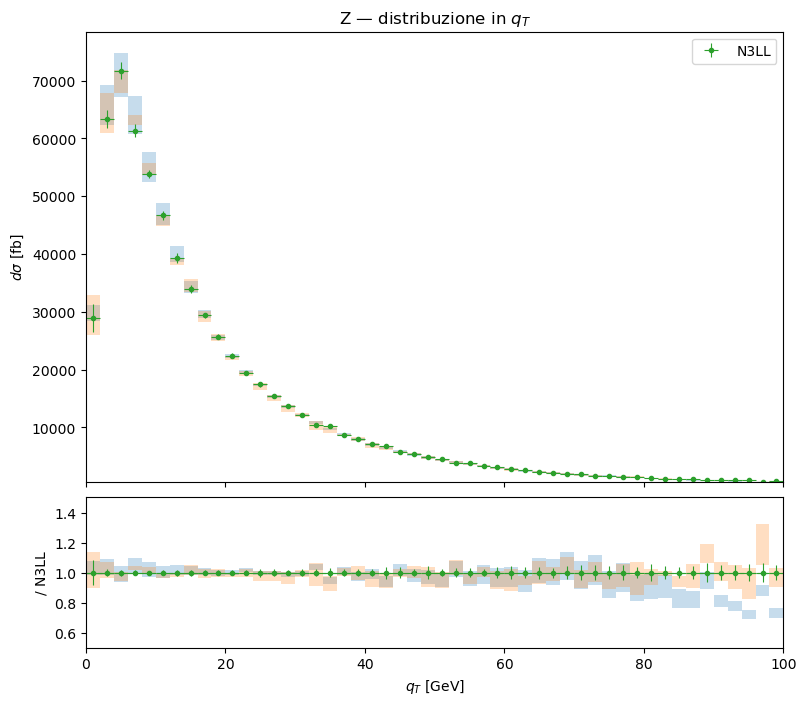

In [28]:
def envelope(df, boson, order, x_col='qt_lo'):
    # Flat approach: upper=max, lower=min over all scale variations.
    # The nominal can fall outside the band if the variations are asymmetric.
    mask = (df.boson == boson) & (df.order == order)
    g = df[mask].groupby(x_col)['value']
    return g.max(), g.min()

# # Nominal-centred approach: the band is symmetric around the nominal.
# # upper = nominal + max(|var - nominal|)
# # lower = nominal - max(|var - nominal|)
# # The nominal is always at the centre of the band by construction.
# def envelope(df, boson, order, x_col='qt_lo'):
#     mask = (df.boson == boson) & (df.order == order)
#     nom_mask = mask & (df.muR == 1.0) & (df.muF == 1.0) & (df.muQ == 1.0)
#     nominal = df[nom_mask].groupby(x_col)['value'].first()
#     deviations = df[mask].groupby(x_col)['value'].apply(
#         lambda vals: (vals - nominal[vals.name]).abs().max()
#     )
#     return nominal + deviations, nominal - deviations

BOSON  = 'Z'   # ← 'Z', 'Wp', 'Wm'
colors = {'NLL': 'C0', 'NNLL': 'C1', 'N3LL': 'C2'}

nom  = nom1d[nom1d.boson == BOSON]
ref  = nom[nom.order == 'N3LL'].set_index('qt_lo')['value']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for order, color in colors.items():
    row = nom[nom.order == order]
    qt  = row['qt_center'].values
    val = row['value'].values
    err = row['error'].values
    w   = (row['qt_hi'] - row['qt_lo']).values   # larghezza bin

    if order == 'N3LL':
        # Scatter + statistical error bars
        ax1.errorbar(qt, val, yerr=err,
                     xerr=w/2, fmt='o', markersize=3,
                     color=color, linewidth=0,
                     elinewidth=0.8, capsize=0, label=order)
        ratio_n3ll     = val / ref.reindex(row['qt_lo']).values
        ratio_n3ll_err = err / ref.reindex(row['qt_lo']).values
        ax2.errorbar(qt, ratio_n3ll, yerr=ratio_n3ll_err,
                     xerr=w/2, fmt='o', markersize=3,
                     color=color, linewidth=0,
                     elinewidth=0.8, capsize=0)
    else:
        # Nominal as a line
        #ax1.step(qt, val, where='mid', color=color, linewidth=1.4, label=order)

        # Envelope as coloured boxes (one rectangle per bin)
        up, lo = envelope(df1d, BOSON, order)
        qt_lo_bins = up.index.values
        ax1.bar(qt_lo_bins, up.values - lo.values, bottom=lo.values,
                width=w, align='edge',
                alpha=0.25, color=color, linewidth=0)

        # Ratio panel
        ratio    = val / ref.reindex(row['qt_lo']).values
        ratio_up = up.values / ref.values
        ratio_lo = lo.values / ref.values
        #ax2.step(qt, ratio, where='mid', color=color)
        ax2.bar(qt_lo_bins, ratio_up - ratio_lo, bottom=ratio_lo,
                width=w, align='edge',
                alpha=0.25, color=color, linewidth=0)

ax2.axhline(1, color='C2', linewidth=0.8, linestyle='--')
#ax1.set_yscale('log')
ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(); ax1.set_title(f'{BOSON} — $q_T$ distribution')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('/ N3LL')
ax2.set_xlim(0, 100); ax2.set_ylim(0.5, 1.5)
plt.show()

## 3 — 2D grid: heatmap (q_T, p_T^l)

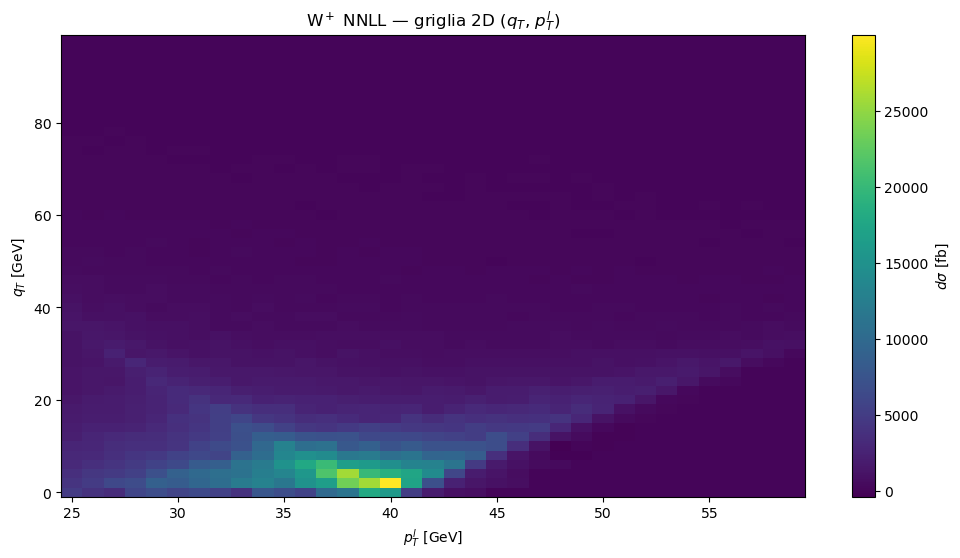

In [29]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'

sel  = df2d_wp.query("order == @ORDER and muF==1.0 and muQ==1.0 and muR==1.0")
grid = sel.pivot_table(index='qt_lo', columns='ptl_lo', values='value')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label=r'$d\sigma$ [fb]')
ax.set_xlabel(r'$p_T^l$ [GeV]'); ax.set_ylabel(r'$q_T$ [GeV]')
ax.set_title(f'W$^+$ {ORDER} — 2D grid ($q_T$, $p_T^l$)')
plt.show()

## 4 — Lookup: value for a specific bin pair

In [30]:
# ── modify these parameters ────────────────────────────────
QT_LO  = 20
PTL_LO = 35
ORDER  = 'NNLL'
BOSON  = 'Wp'   # 'Wp' o 'Wm'
MUR, MUF, MUQ = 1.0, 1.0, 1.0
# ───────────────────────────────────────────────────────────

df2d = df2d_wp if BOSON == 'Wp' else df2d_wm
row  = df2d.query(
    "order==@ORDER and muR==@MUR and muF==@MUF and muQ==@MUQ "
    "and qt_lo==@QT_LO and ptl_lo==@PTL_LO"
)

if row.empty:
    print(f'Nessun bin trovato per qt_lo={QT_LO}, ptl_lo={PTL_LO}')
    print(f'qt  disponibili: {sorted(df2d.qt_lo.unique().tolist())}')
    print(f'ptl disponibili: {sorted(df2d.ptl_lo.unique().tolist())}')
else:
    r = row.iloc[0]
    print(f'Boson: {BOSON}  |  Ordine: {ORDER}  |  muR={MUR}  muF={MUF}  muQ={MUQ}')
    print(f'qt  ∈ [{r.qt_lo:.0f}, {r.qt_hi:.0f}] GeV')
    print(f'ptl ∈ [{r.ptl_lo:.0f}, {r.ptl_hi:.0f}] GeV')
    print(f'valore : {r.value:.6g} pb')
    print(f'errore : {r.error:.6g} pb  ({100*r.error/abs(r.value):.2f}%)')

Boson: Wp  |  Ordine: NNLL  |  muR=1.0  muF=1.0  muQ=1.0
qt  ∈ [20, 22] GeV
ptl ∈ [35, 36] GeV
valore : 2553.05 pb
errore : 151.29 pb  (5.93%)


## 5 — Comparison: 2D→q_T projection vs 1D distribution

The q_T projection is precomputed in `2D.root` as `proj_qt`.  
The comparison with the 1D distribution shows the cross-section fraction covered by the fiducial region p_T^l ∈ [25,60] GeV.

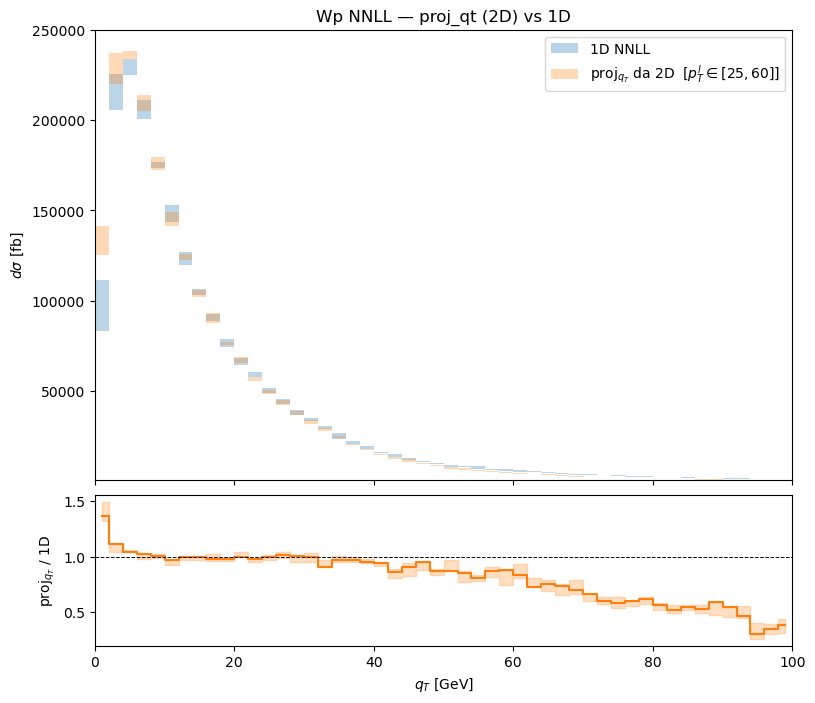

In [31]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'

nom = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"

w1d  = df1d.query(f"boson=='{BOSON}' and {nom}").set_index('qt_lo').sort_index()
wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom}").set_index('qt_lo').sort_index()

common = sorted(set(w1d.index) & set(wpqt.index))
qt_c   = w1d.loc[common, 'qt_center'].values
w_arr  = (w1d.loc[common, 'qt_hi'] - np.array(common)).values
v1d,  e1d  = w1d.loc[common,  'value'].values, w1d.loc[common,  'error'].values
vpqt, epqt = wpqt.loc[common, 'value'].values, wpqt.loc[common, 'error'].values

up_1d,  lo_1d  = envelope(df1d,   BOSON, ORDER, x_col='qt_lo')
up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(qt_c, v1d,  yerr=e1d,  xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0, label=f'1D {ORDER}')
    ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{q_T}$ from 2D  [$p_T^l\in[25,60]$]')
else:
    ax1.bar(np.array(common), (up_1d.reindex(common)-lo_1d.reindex(common)).values,
            bottom=lo_1d.reindex(common).values, width=w_arr, align='edge',
            alpha=0.30, color='C0', linewidth=0, label=f'1D {ORDER}')
    # ax1.step(qt_c, v1d, where='mid', color='C0')
    ax1.bar(np.array(common), (up_pqt.reindex(common)-lo_pqt.reindex(common)).values,
            bottom=lo_pqt.reindex(common).values, width=w_arr, align='edge',
            alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{q_T}$ from 2D  [$p_T^l\in[25,60]$]')
    # ax1.step(qt_c, vpqt, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj_qt (2D) vs 1D')

ratio     = vpqt / v1d
ratio_err = epqt / v1d  # ratio * np.sqrt((epqt/vpqt)**2 + (e1d/v1d)**2)
ratio_up  = up_pqt / v1d
ratio_lo  = lo_pqt / v1d
if ORDER == 'N3LL':
    ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ax2.step(qt_c, ratio, where='mid', color='C1')
    ax2.fill_between(qt_c, ratio_lo, ratio_up, step='mid', alpha=0.25, color='C1')

ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('proj$_{q_T}$ / 1D')
ax2.set_xlim(0, 100)
plt.show()


## 6 — Distribution in p_T^l: 2D projection and order comparison

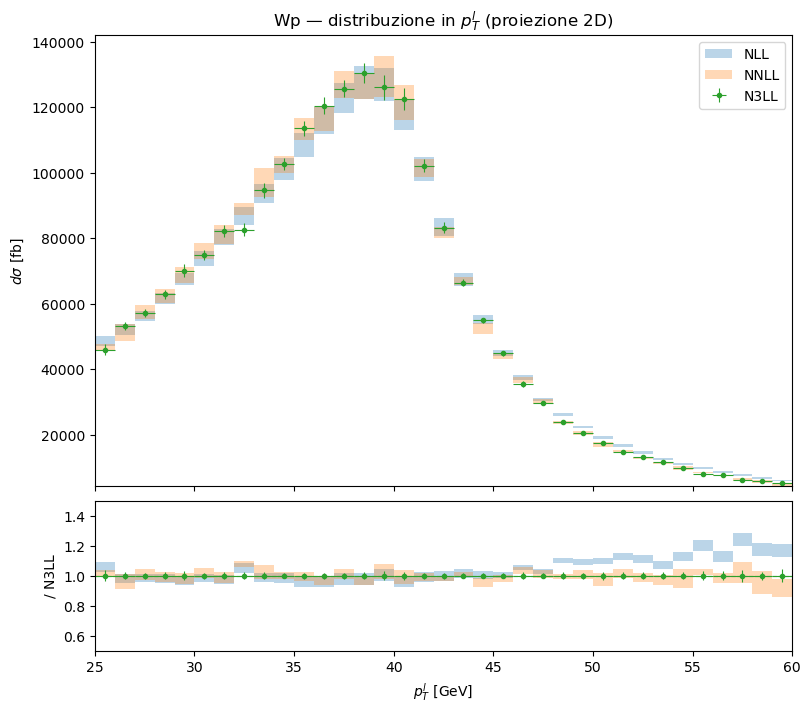

In [32]:
# NLL / NNLL / N3LL comparison for the p_T^l projection
BOSON  = 'Wp'   # ← 'Wp' o 'Wm'
colors = {'NLL': 'C0', 'NNLL': 'C1', 'N3LL': 'C2'}

nom_ptl = df_pptl.query("muF==1.0 and muQ==1.0 and muR==1.0")
ref_ptl = nom_ptl.query(f"boson=='{BOSON}' and order=='N3LL'").set_index('ptl_lo')['value']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for order, color in colors.items():
    row = nom_ptl.query(f"boson=='{BOSON}' and order=='{order}'")
    ptl = row['ptl_center'].values
    val = row['value'].values
    err = row['error'].values
    w   = (row['ptl_hi'] - row['ptl_lo']).values

    if order == 'N3LL':
        ax1.errorbar(ptl, val, yerr=err, xerr=w/2,
                     fmt='o', markersize=3, color=color, linewidth=0,
                     elinewidth=0.8, capsize=0, label=order)
        ratio_n3ll     = val / ref_ptl.reindex(row['ptl_lo']).values
        ratio_n3ll_err = err / ref_ptl.reindex(row['ptl_lo']).values
        ax2.errorbar(ptl, ratio_n3ll, yerr=ratio_n3ll_err, xerr=w/2,
                     fmt='o', markersize=3, color=color, linewidth=0,
                     elinewidth=0.8, capsize=0)
    else:
        up, lo = envelope(df_pptl, BOSON, order, x_col='ptl_lo')
        # ax1.step(ptl, val, where='mid', color=color, linewidth=1.2)
        ax1.bar(row['ptl_lo'].values, (up - lo).values, bottom=lo.values,
                width=w, align='edge', alpha=0.30, color=color, linewidth=0, label=order)
        ratio    = val / ref_ptl.reindex(row['ptl_lo']).values
        ratio_up = up.values / ref_ptl.values
        ratio_lo = lo.values / ref_ptl.values
        ax2.bar(row['ptl_lo'].values, ratio_up - ratio_lo, bottom=ratio_lo,
                width=w, align='edge', alpha=0.30, color=color, linewidth=0)

ax2.axhline(1, color='C2', linewidth=0.8, linestyle='--')
ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(); ax1.set_title(f'{BOSON} — $p_T^l$ distribution (2D projection)')
ax2.set_xlabel(r'$p_T^l$ [GeV]'); ax2.set_ylabel('/ N3LL')
ax2.set_xlim(25, 60); ax2.set_ylim(0.5, 1.5)
plt.show()


## 7 — Comparison: proj_ptl vs direct 2D sum over $q_T$

For each $p_T^l$ bin, all $q_T$ bins of the 2D grid are summed (errors in quadrature).  
The result should match the precomputed projection `proj_ptl`.

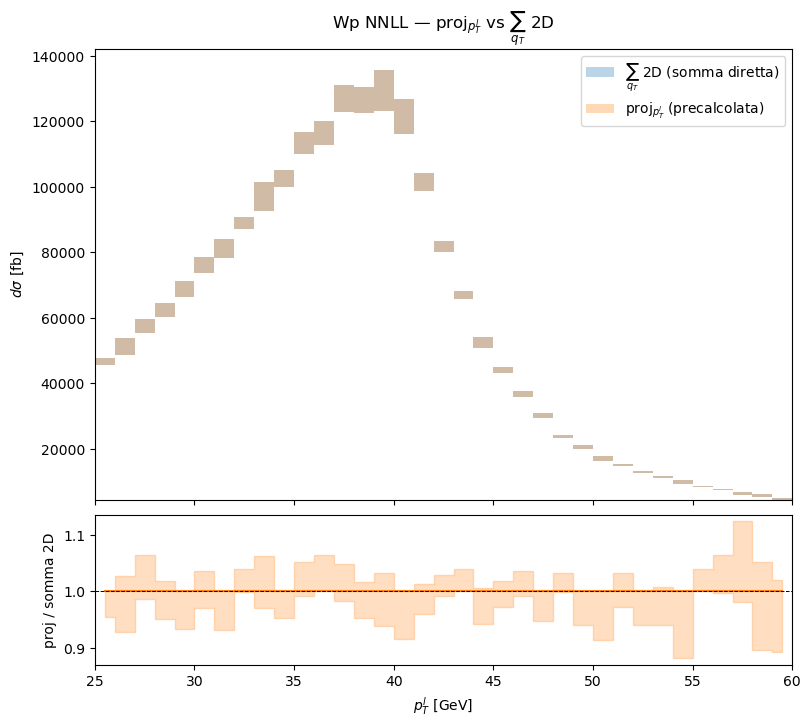

In [33]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'     # ← 'Wp', 'Wm'

nom_q = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"
df2d  = df2d_wp if BOSON == 'Wp' else df2d_wm

nom2d   = df2d.query(nom_q)
sum_ptl = (nom2d.groupby('ptl_lo')
                .agg(value=('value', 'sum'),
                     error=('error', lambda x: np.sqrt((x**2).sum())))
                .sort_index())

wpptl = df_pptl.query(f"boson=='{BOSON}' and {nom_q}").set_index('ptl_lo').sort_index()

common  = sorted(set(sum_ptl.index) & set(wpptl.index))
ptl_c   = wpptl.loc[common, 'ptl_center'].values
w_arr   = (wpptl.loc[common, 'ptl_hi'] - np.array(common)).values
v2d,  e2d    = sum_ptl.loc[common, 'value'].values,  sum_ptl.loc[common, 'error'].values
vpptl, epptl = wpptl.loc[common, 'value'].values,    wpptl.loc[common, 'error'].values

g_env_2d = (df2d[df2d.order == ORDER]
             .groupby(['muR','muF','muQ','ptl_lo'])['value'].sum()
             .reset_index().groupby('ptl_lo')['value'])
up_2d     = g_env_2d.max().reindex(common).values
lo_2d     = g_env_2d.min().reindex(common).values

up_pptl, lo_pptl = envelope(df_pptl, BOSON, ORDER, x_col='ptl_lo')
up_pptl_c = up_pptl.reindex(common).values
lo_pptl_c = lo_pptl.reindex(common).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(ptl_c, v2d,   yerr=e2d,   xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'$\sum_{q_T}$ 2D (direct sum)')
    ax1.errorbar(ptl_c, vpptl, yerr=epptl, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{p_T^l}$ (precomputed)')
else:
    ax1.bar(np.array(common), up_2d - lo_2d, bottom=lo_2d,
            width=w_arr, align='edge', alpha=0.30, color='C0', linewidth=0,
            label=r'$\sum_{q_T}$ 2D (direct sum)')
    # ax1.step(ptl_c, v2d, where='mid', color='C0')
    ax1.bar(np.array(common), up_pptl_c - lo_pptl_c, bottom=lo_pptl_c,
            width=w_arr, align='edge', alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{p_T^l}$ (precomputed)')
    # ax1.step(ptl_c, vpptl, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj$_{{p_T^l}}$ vs $\sum_{{q_T}}$ 2D')

ratio     = vpptl / v2d
if ORDER == 'N3LL':
    ratio_err = epptl / v2d
    ax2.errorbar(ptl_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ratio_up = up_pptl_c / v2d
    ratio_lo = lo_pptl_c / v2d
    ax2.step(ptl_c, ratio, where='mid', color='C1')
    ax2.fill_between(ptl_c, ratio_lo, ratio_up, step='mid', alpha=0.25, color='C1')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$p_T^l$ [GeV]'); ax2.set_ylabel('proj / direct sum 2D')
ax2.set_xlim(25, 60)
plt.show()


## 8 — Comparison: proj_qT vs direct 2D sum over p_T^l

For each $q_T$ bin, all $p_T^l$ bins of the 2D grid are summed (errors in quadrature).  
The result should match the precomputed projection `proj_qt`.

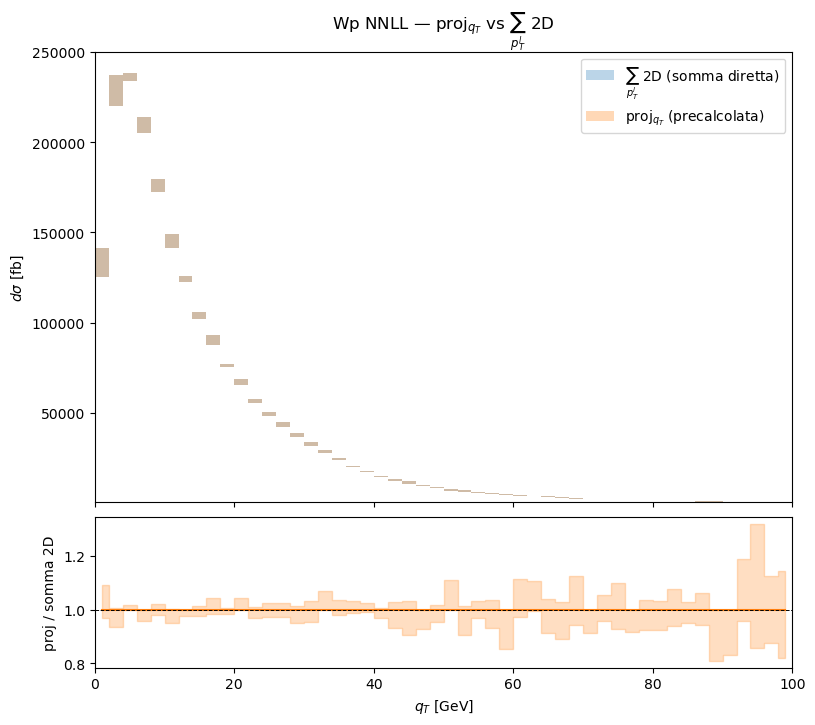

In [34]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'     # ← 'Wp', 'Wm'

nom_q = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"
df2d  = df2d_wp if BOSON == 'Wp' else df2d_wm

nom2d  = df2d.query(nom_q)
sum_qt = (nom2d.groupby('qt_lo')
               .agg(value=('value', 'sum'),
                    error=('error', lambda x: np.sqrt((x**2).sum())))
               .sort_index())

wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()

common = sorted(set(sum_qt.index) & set(wpqt.index))
qt_c   = wpqt.loc[common, 'qt_center'].values
w_arr  = (wpqt.loc[common, 'qt_hi'] - np.array(common)).values
v2d,  e2d   = sum_qt.loc[common, 'value'].values, sum_qt.loc[common, 'error'].values
vpqt, epqt  = wpqt.loc[common, 'value'].values,   wpqt.loc[common, 'error'].values

g_env_2d = (df2d[df2d.order == ORDER]
             .groupby(['muR','muF','muQ','qt_lo'])['value'].sum()
             .reset_index().groupby('qt_lo')['value'])
up_2d     = g_env_2d.max().reindex(common).values
lo_2d     = g_env_2d.min().reindex(common).values

up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')
up_pqt_c = up_pqt.reindex(common).values
lo_pqt_c = lo_pqt.reindex(common).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(qt_c, v2d,  yerr=e2d,  xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'$\sum_{p_T^l}$ 2D (direct sum)')
    ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{q_T}$ (precomputed)')
else:
    ax1.bar(np.array(common), up_2d - lo_2d, bottom=lo_2d,
            width=w_arr, align='edge', alpha=0.30, color='C0', linewidth=0,
            label=r'$\sum_{p_T^l}$ 2D (direct sum)')
    # ax1.step(qt_c, v2d, where='mid', color='C0')
    ax1.bar(np.array(common), up_pqt_c - lo_pqt_c, bottom=lo_pqt_c,
            width=w_arr, align='edge', alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{q_T}$ (precomputed)')
    # ax1.step(qt_c, vpqt, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj$_{{q_T}}$ vs $\sum_{{p_T^l}}$ 2D')

ratio     = vpqt / v2d
if ORDER == 'N3LL':
    ratio_err = epqt / v2d
    ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ratio_up = up_pqt_c / v2d
    ratio_lo = lo_pqt_c / v2d
    ax2.step(qt_c, ratio, where='mid', color='C1')
    ax2.fill_between(qt_c, ratio_lo, ratio_up, step='mid', alpha=0.25, color='C1')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('proj / direct sum 2D')
ax2.set_xlim(0, 100)
plt.show()


## 9 — Comparison: 1D vs proj_qT  (NNLL & N3LL)

- **C0** (blue): inclusive 1D distribution in $q_T$
- **C1** (orange): proj$_{q_T}$ — only $p_T^l \in [25,60]$ GeV
- **bars**: NNLL — scale envelope (min/max variations)
- **scatter**: N3LL — pseudo-data with Monte Carlo uncertainty

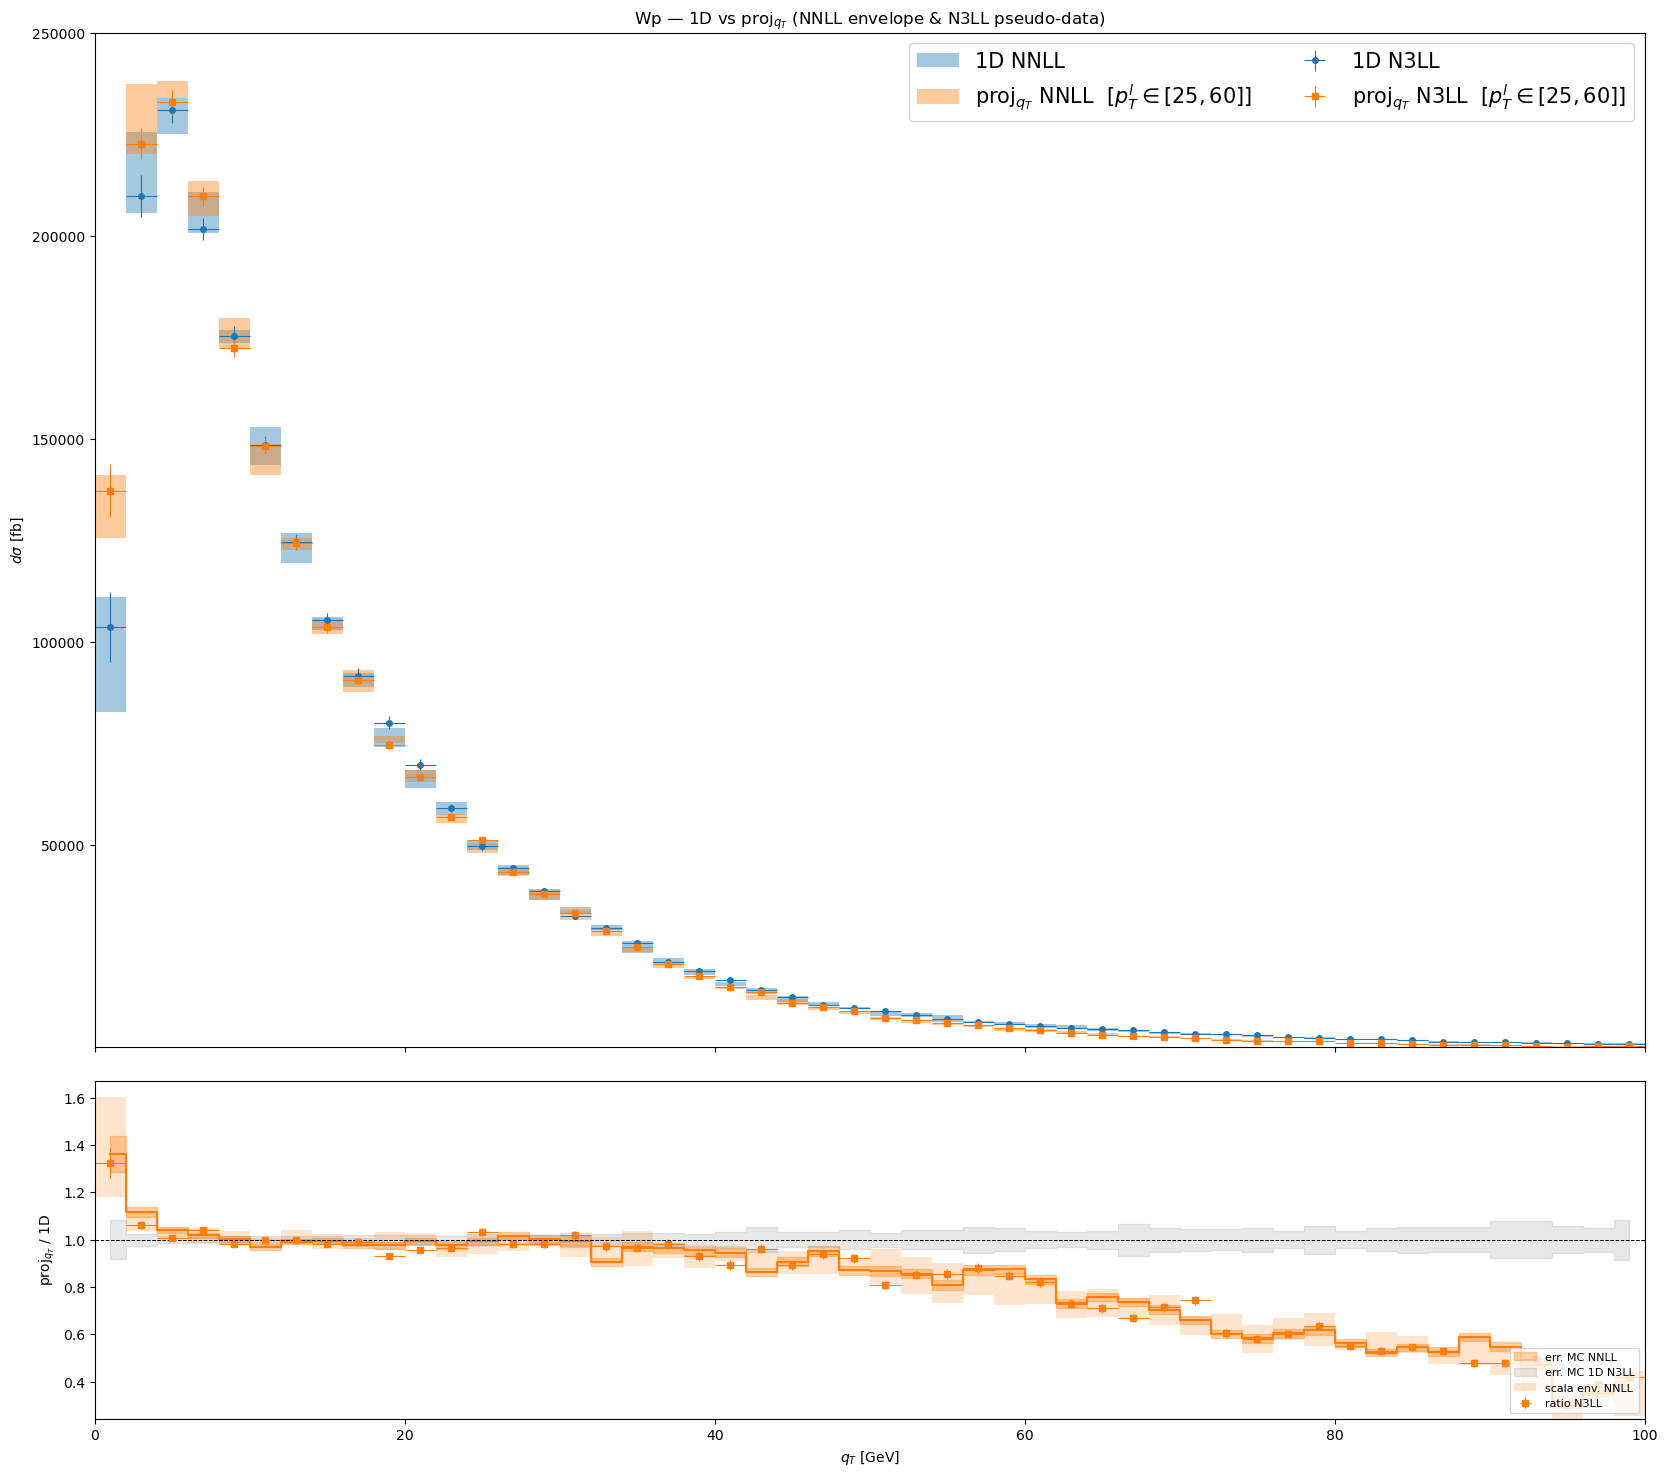

In [35]:
BOSON    = 'Wp'   # ← 'Wp', 'Wm'
nom_base = "muF==1.0 and muQ==1.0 and muR==1.0"

# C0 = 1D  |  C1 = proj_qT  |  bar = NNLL envelope  |  scatter = N3LL pseudo-data
COL_1D   = 'C0'
COL_PROJ = 'C1'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 18), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for ORDER in ['NNLL', 'N3LL']:
    nom_q = f"order=='{ORDER}' and {nom_base}"

    w1d  = df1d.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()
    wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()

    common = sorted(set(w1d.index) & set(wpqt.index))
    qt_c   = w1d.loc[common, 'qt_center'].values
    w_arr  = (w1d.loc[common, 'qt_hi'] - np.array(common)).values
    v1d,   e1d  = w1d.loc[common,  'value'].values, w1d.loc[common,  'error'].values
    vpqt,  epqt = wpqt.loc[common, 'value'].values, wpqt.loc[common, 'error'].values

    up_1d,  lo_1d  = envelope(df1d,   BOSON, ORDER, x_col='qt_lo')
    up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')

    ratio     = vpqt / v1d
    ratio_err = epqt / v1d

    if ORDER == 'N3LL':
        # ── upper panel ────────────────────────────────────────────────────
        ax1.errorbar(qt_c, v1d,  yerr=e1d,  xerr=w_arr/2,
                     fmt='o', markersize=4, color=COL_1D, linewidth=0,
                     elinewidth=0.8, capsize=0, label=f'1D {ORDER}')
        ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2,
                     fmt='s', markersize=4, color=COL_PROJ, linewidth=0,
                     elinewidth=0.8, capsize=0,
                     label=rf'proj$_{{q_T}}$ {ORDER}  [$p_T^l\in[25,60]$]')
        # ── ratio panel ────────────────────────────────────────────────────
        # grey band: MC uncertainty of the 1D distribution (ratio denominator)
        e1d_rel = e1d / v1d
        ax2.fill_between(qt_c, 1 - e1d_rel, 1 + e1d_rel,
                         step='mid', alpha=0.18, color='gray',
                         label='MC err. 1D N3LL')
        # ratio scatter with MC error of the numerator (proj)
        ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2,
                     fmt='s', markersize=4, color=COL_PROJ, linewidth=0,
                     elinewidth=0.8, capsize=0, label='ratio N3LL')

    else:  # NNLL ─────────────────────────────────────────────────────────
        # ── upper panel ────────────────────────────────────────────────────
        ax1.bar(np.array(common),
                (up_1d.reindex(common) - lo_1d.reindex(common)).values,
                bottom=lo_1d.reindex(common).values,
                width=w_arr, align='edge', alpha=0.40, color=COL_1D,
                linewidth=0, label=f'1D {ORDER}')
        # ax1.step(qt_c, v1d, where='mid', color=COL_1D)  # nominal
        ax1.bar(np.array(common),
                (up_pqt.reindex(common) - lo_pqt.reindex(common)).values,
                bottom=lo_pqt.reindex(common).values,
                width=w_arr, align='edge', alpha=0.40, color=COL_PROJ,
                linewidth=0, label=rf'proj$_{{q_T}}$ {ORDER}  [$p_T^l\in[25,60]$]')
        # ax1.step(qt_c, vpqt, where='mid', color=COL_PROJ, linestyle='--')  # nominal

        # ── ratio envelope: ratio(μ) = proj(μ)/1D(μ) for each scale variation
        proj_sc = (df_pqt[(df_pqt.boson == BOSON) & (df_pqt.order == ORDER)]
                   [['muR','muF','muQ','qt_lo','value']]
                   .rename(columns={'value': 'vp'}))
        id1d_sc = (df1d[(df1d.boson == BOSON) & (df1d.order == ORDER)]
                   [['muR','muF','muQ','qt_lo','value']]
                   .rename(columns={'value': 'v1'}))
        merged = proj_sc.merge(id1d_sc, on=['muR','muF','muQ','qt_lo'])
        merged['r'] = merged['vp'] / merged['v1']
        g_ratio = merged[merged['qt_lo'].isin(common)].groupby('qt_lo')['r']
        up_re = g_ratio.max().reindex(common).values
        lo_re = g_ratio.min().reindex(common).values

        # ── ratio panel ────────────────────────────────────────────────────
        # scale envelope (wider, more transparent bar)
        ax2.bar(np.array(common), up_re - lo_re, bottom=lo_re,
                width=w_arr, align='edge', alpha=0.20, color=COL_PROJ,
                linewidth=0, label='scale env. NNLL')
        # nominal + MC stat error (narrower, more opaque)
        ax2.step(qt_c, ratio, where='mid', color=COL_PROJ, linewidth=1.6)
        ax2.fill_between(qt_c, ratio - ratio_err, ratio + ratio_err,
                         step='mid', alpha=0.35, color=COL_PROJ,
                         label='MC err. NNLL')

ax1.set_ylabel(r'$d\sigma$ [fb]')
ax1.legend(ncols=2, fontsize=15)
ax1.set_title(f'{BOSON} — 1D vs proj$_{{q_T}}$ (NNLL envelope & N3LL pseudo-data)')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel(r'proj$_{{q_T}}$ / 1D')
ax2.set_xlim(0, 100)
plt.show()


## 10 — Z: ratio (order, scale variation) / N3LL  —  individual plots

A separate plot for each admissible $(\mu_R, \mu_F, \mu_Q)$ combination, for NLL and NNLL.  
Coloured band = propagated MC error; grey band = relative N3LL uncertainty.

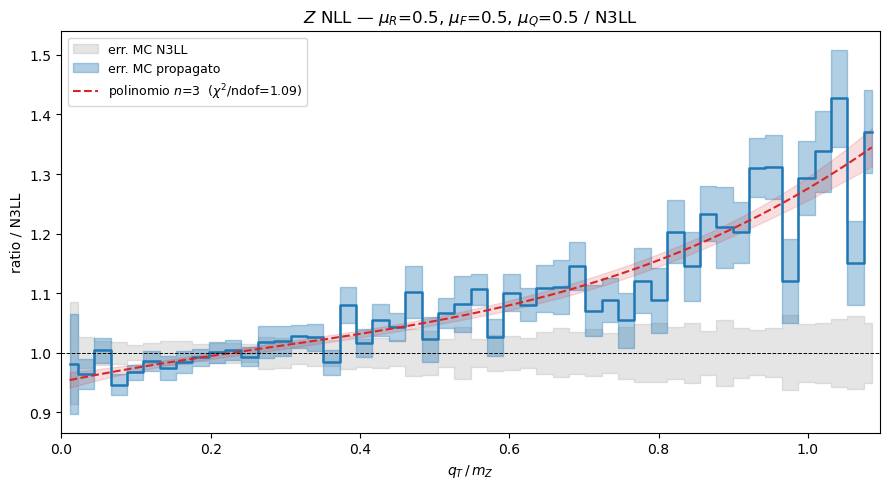

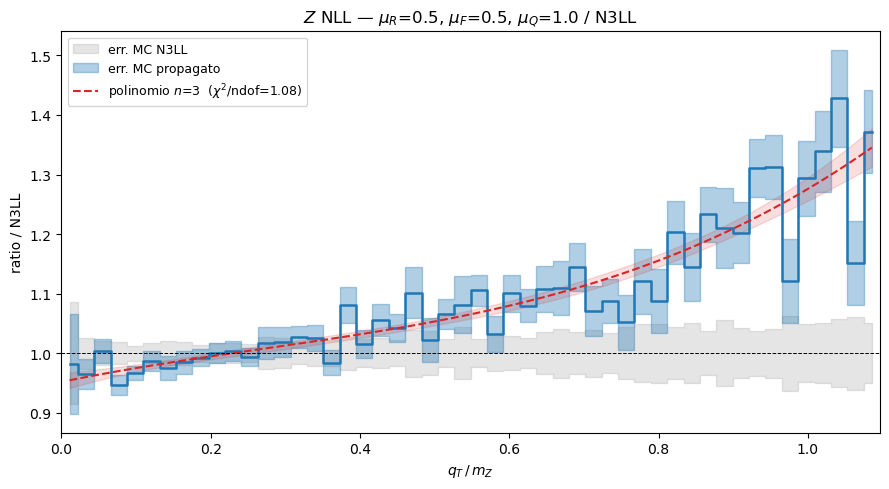

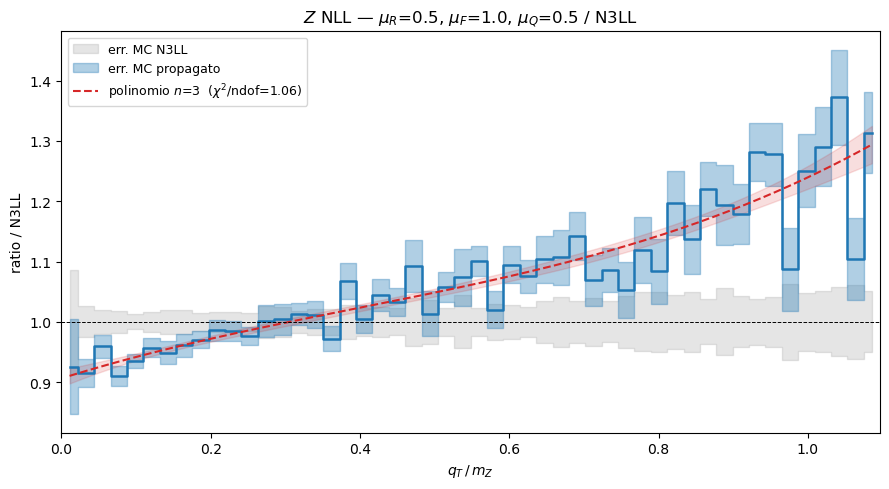

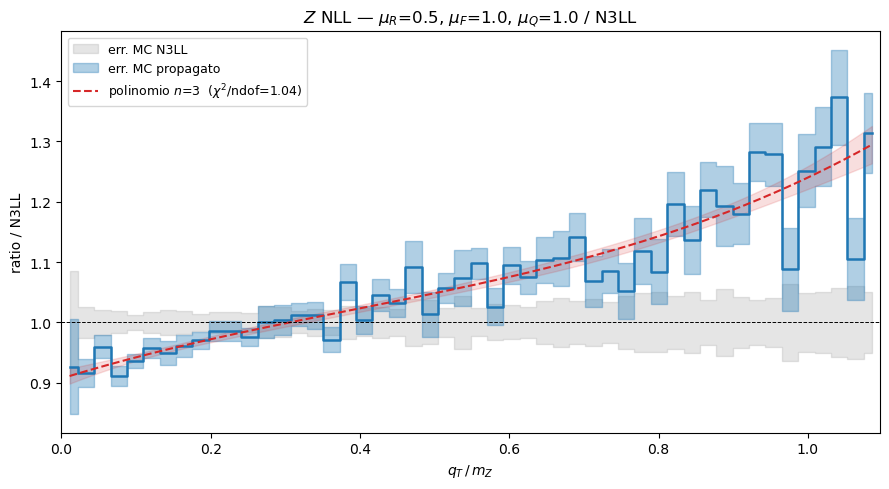

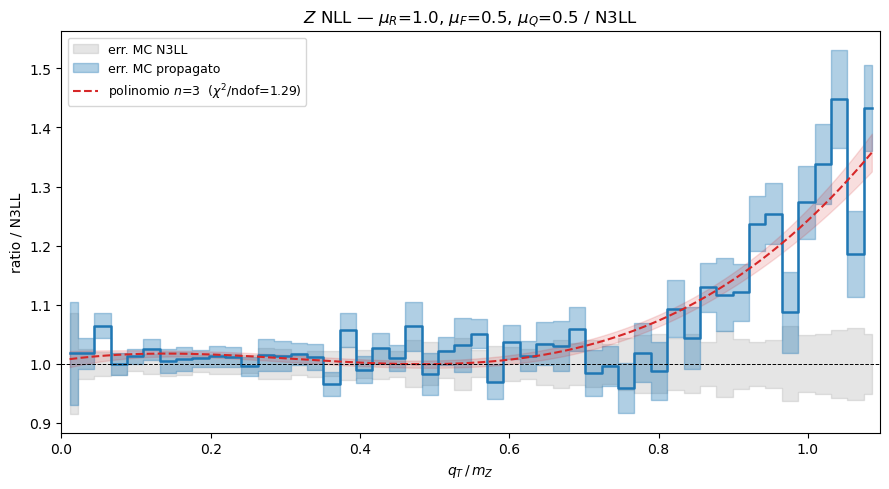

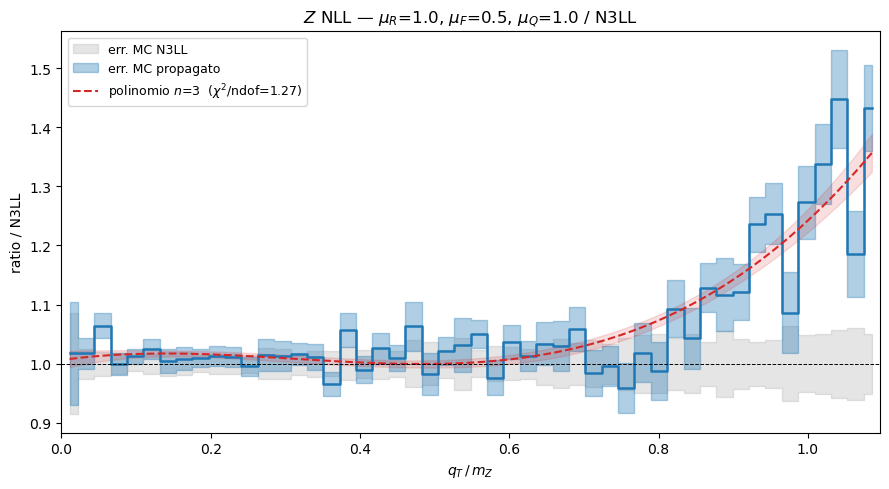

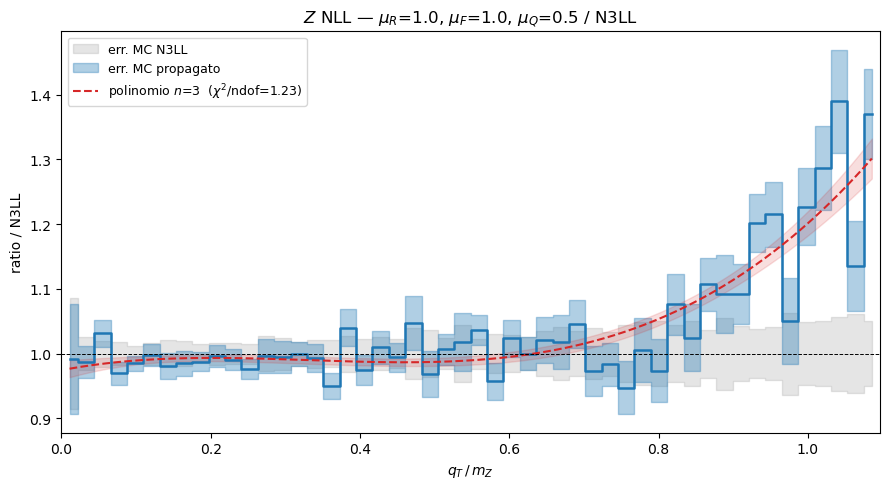

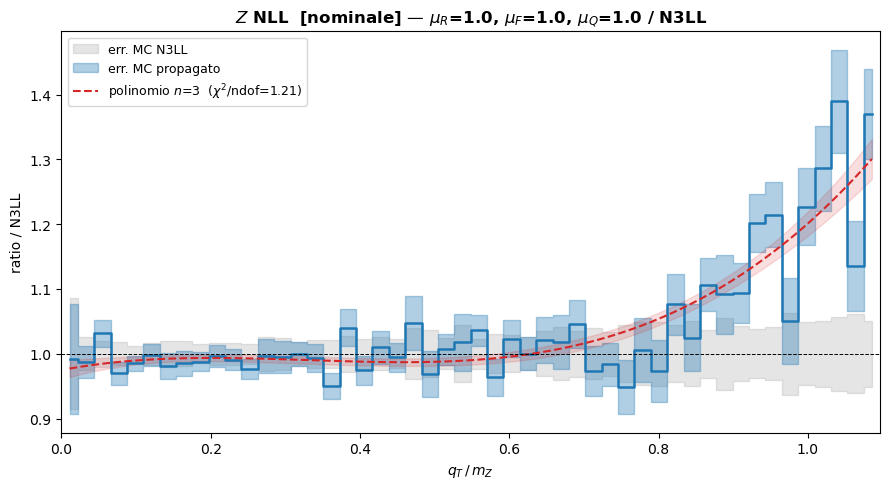

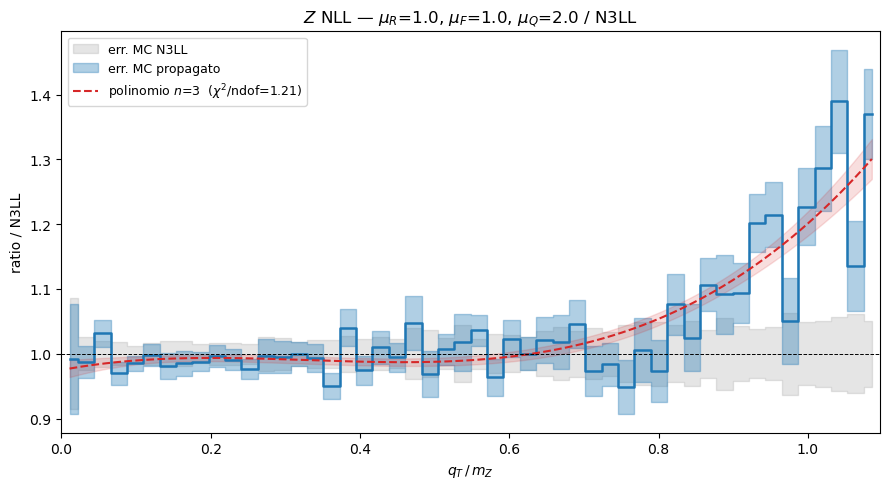

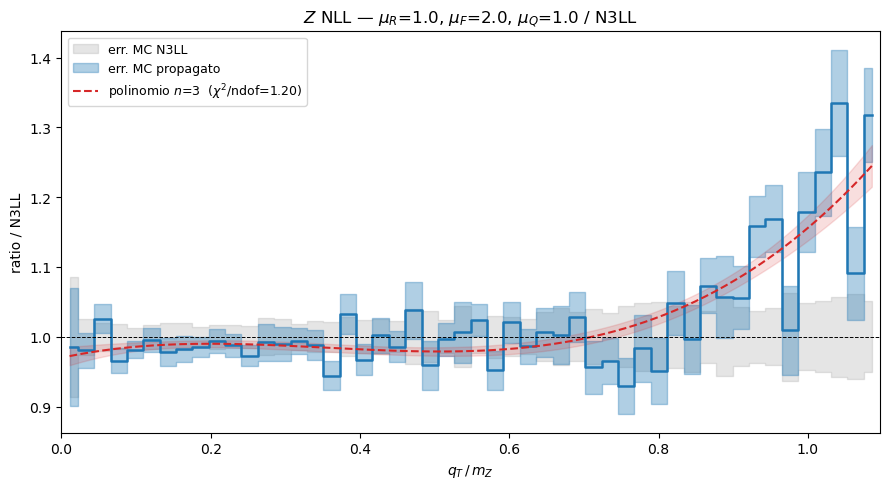

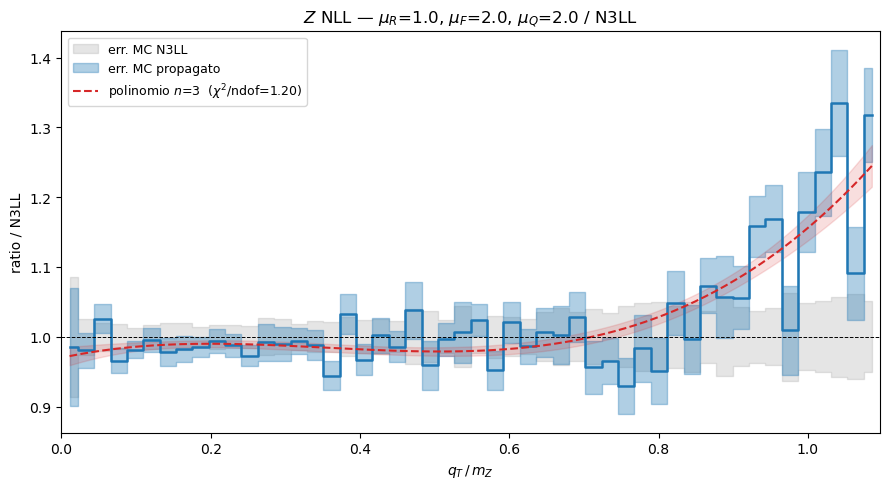

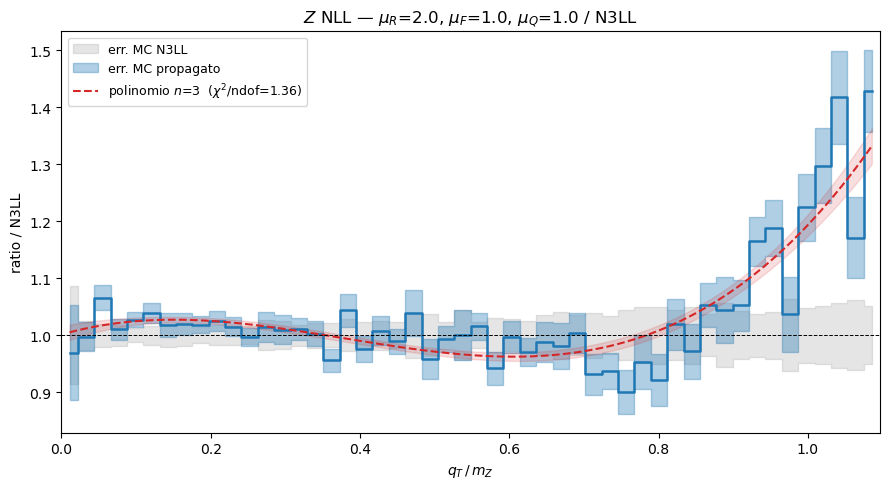

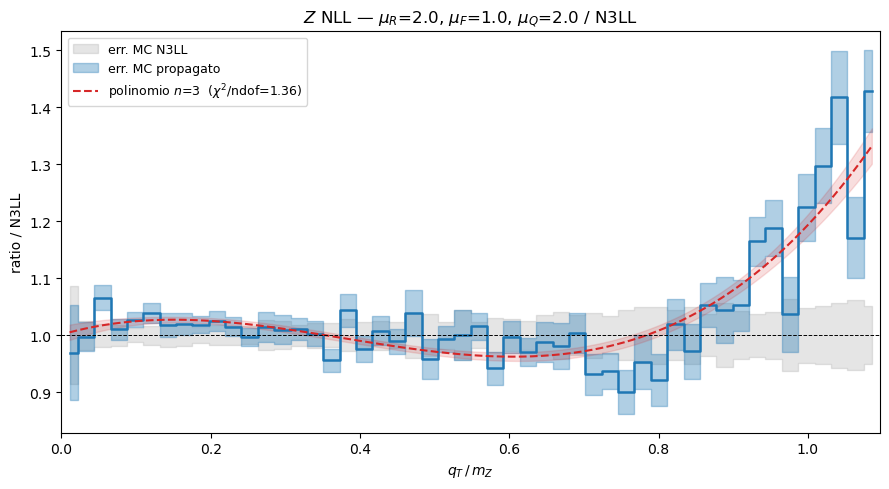

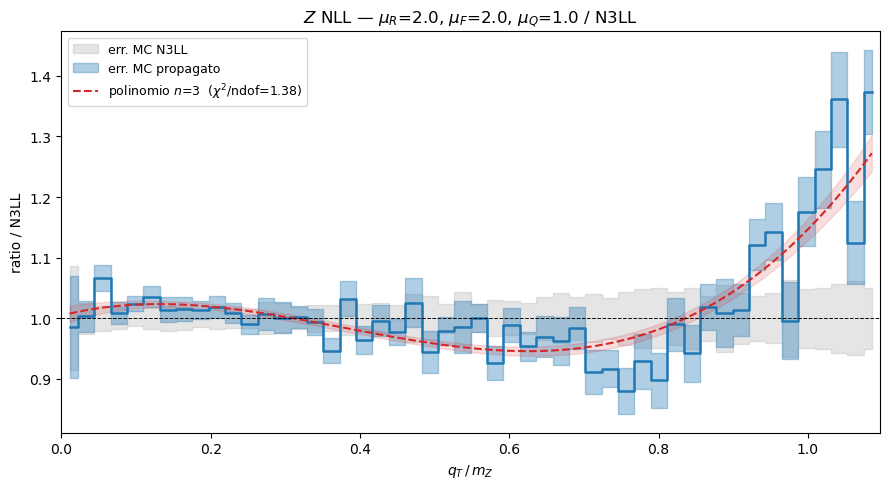

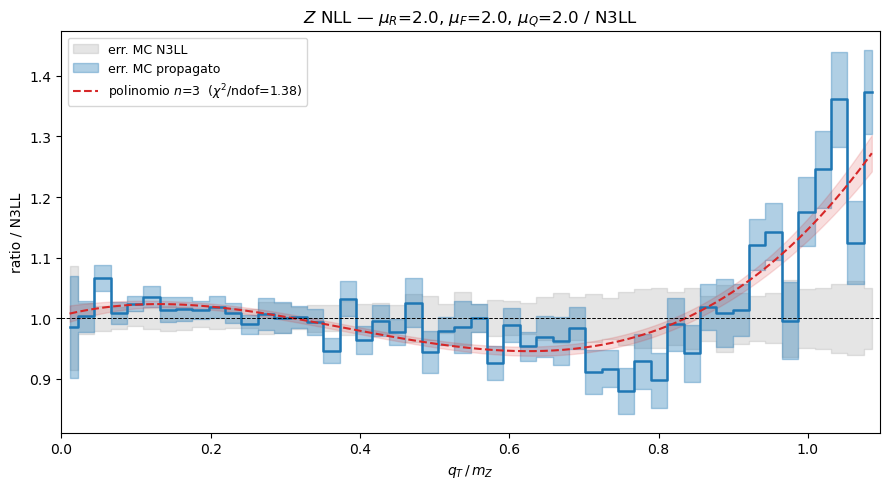

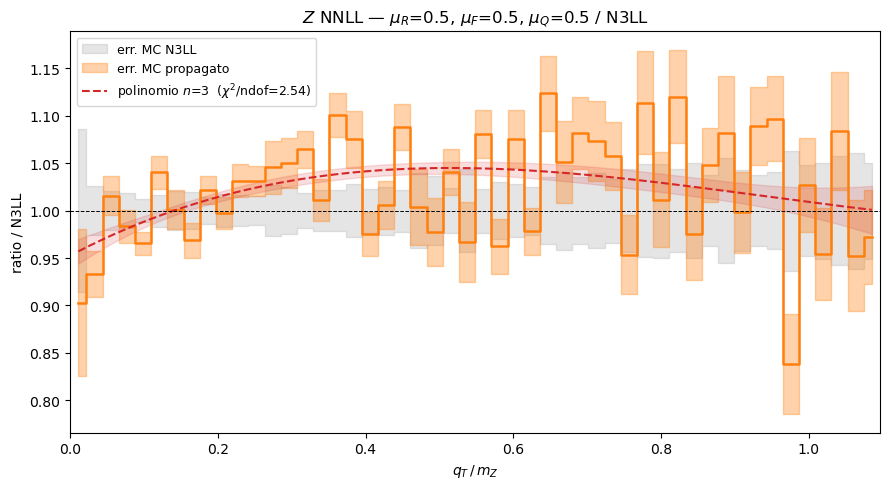

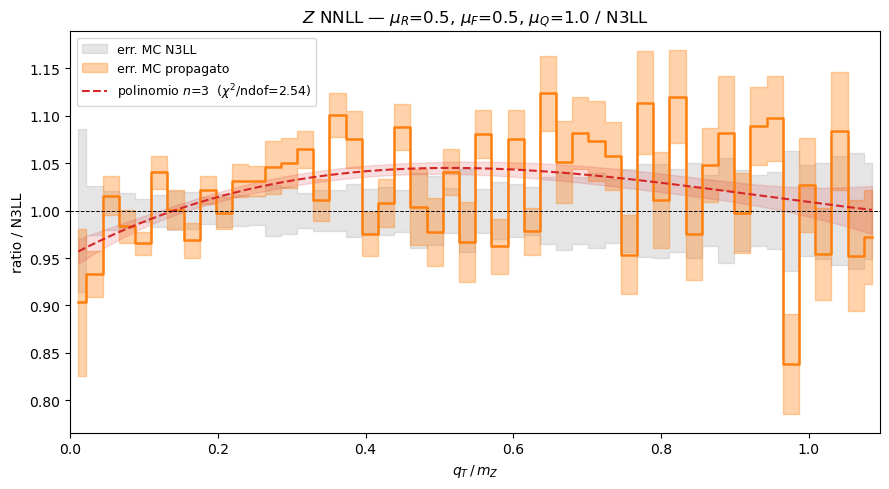

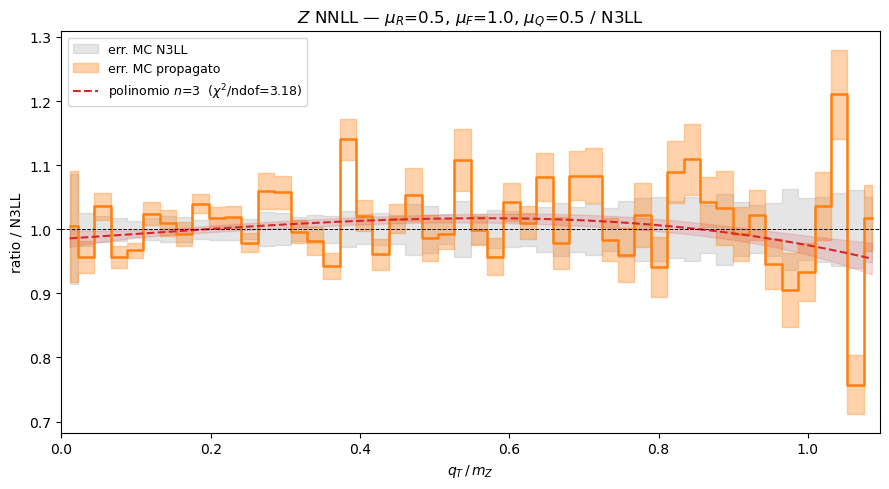

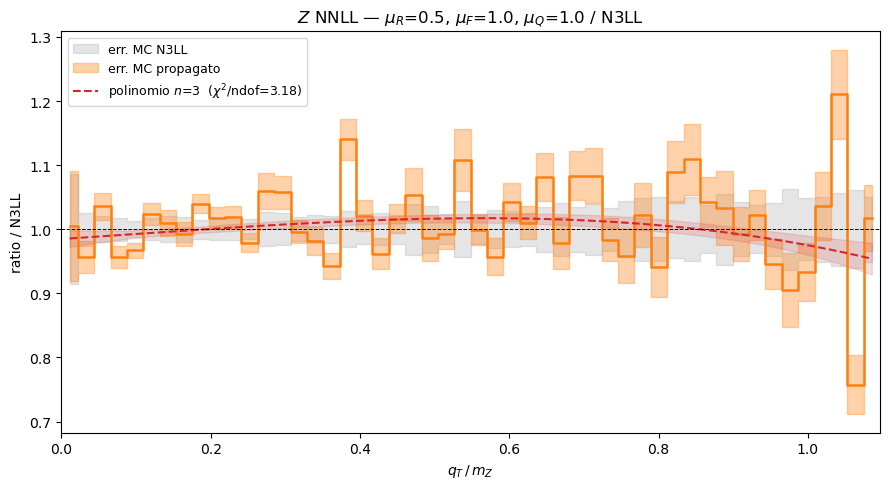

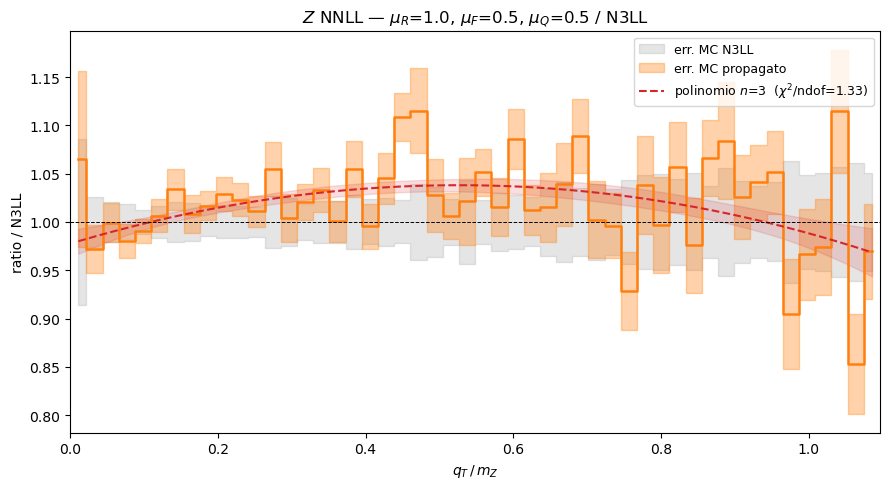

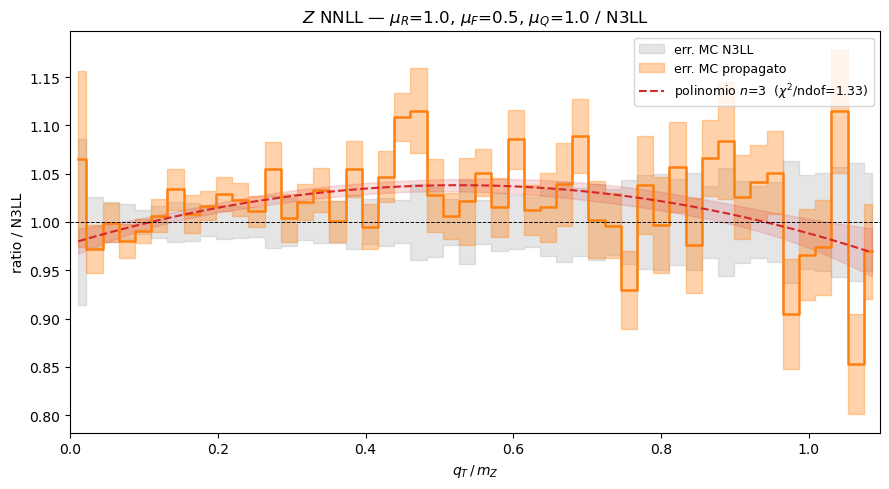

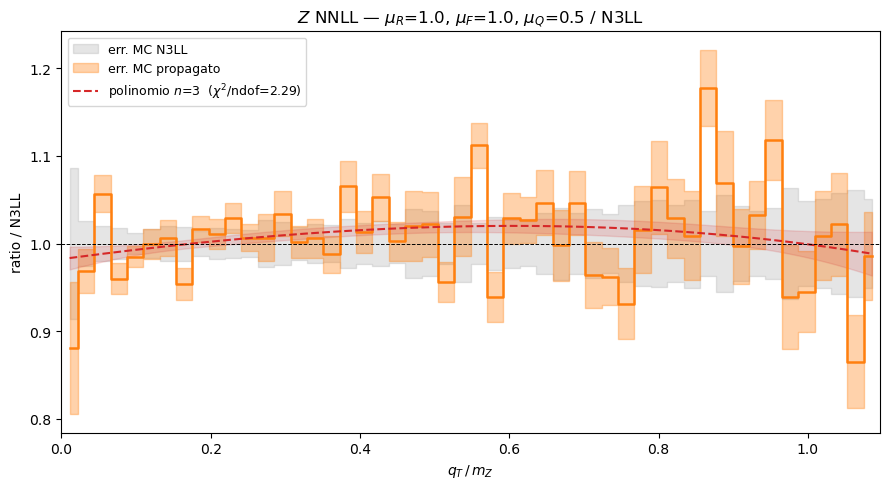

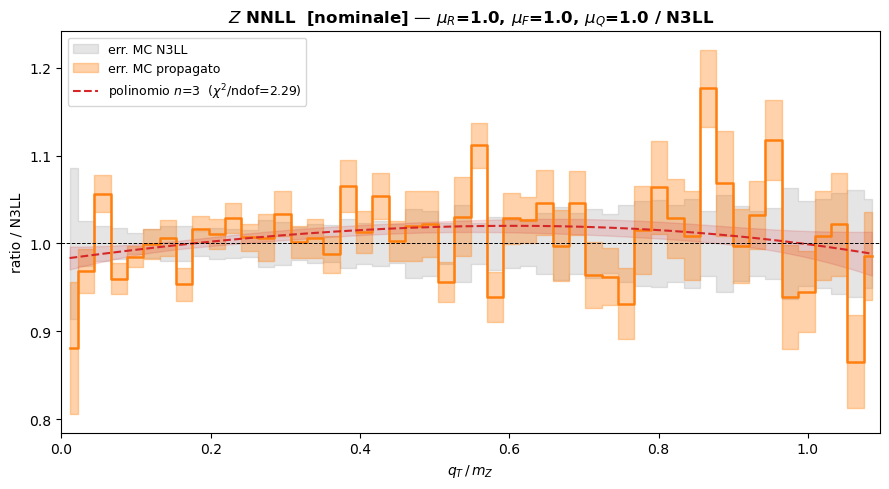

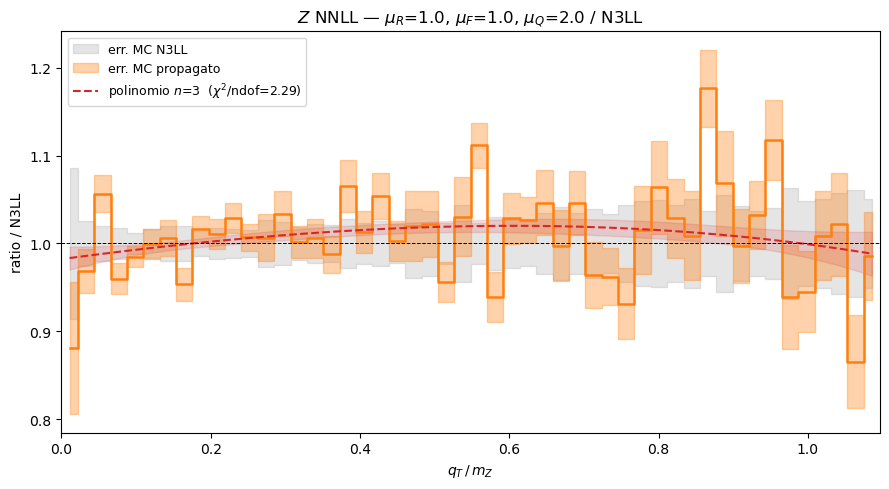

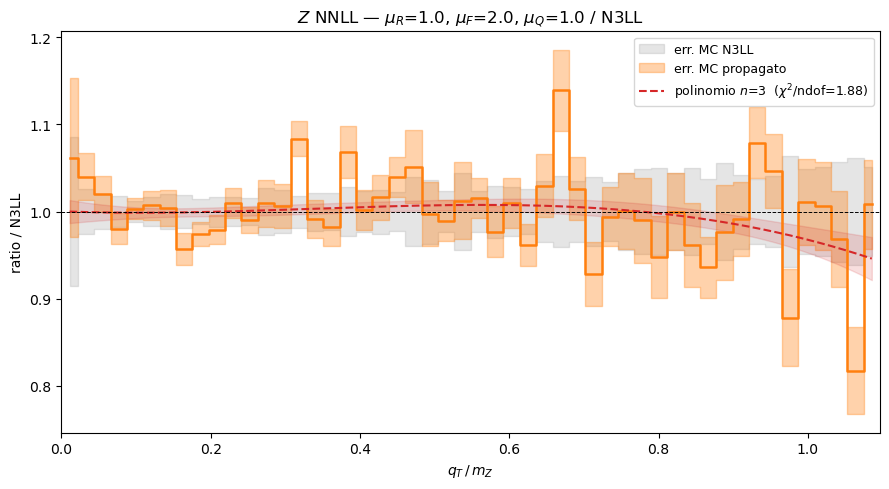

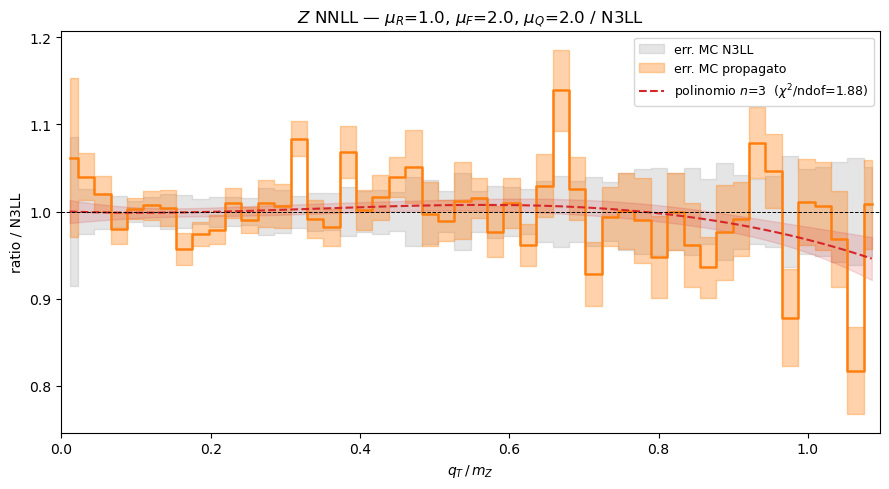

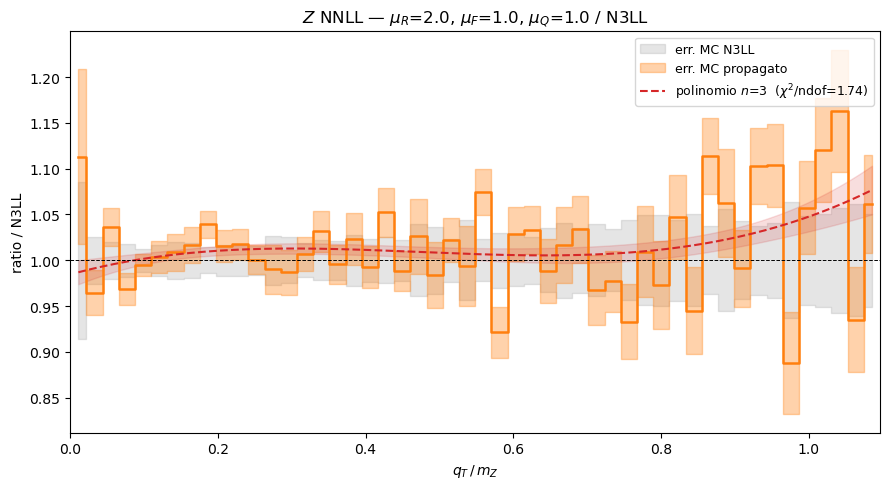

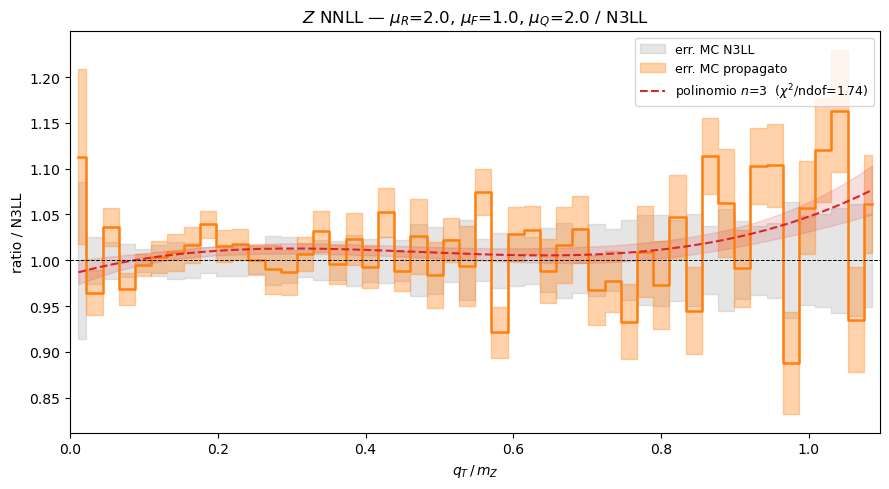

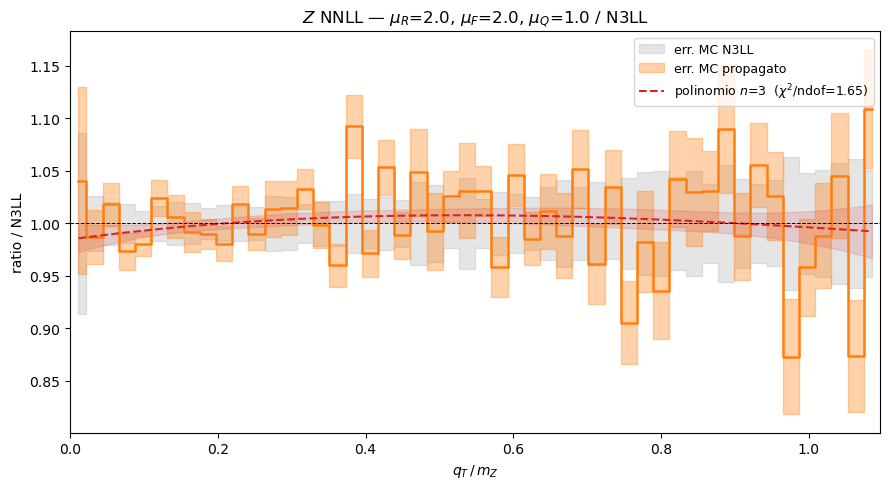

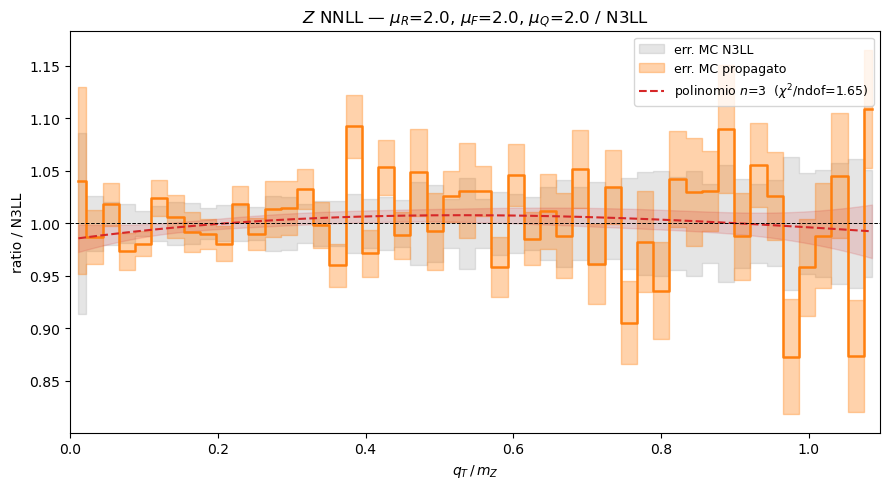

Fit salvati: 30 combinazioni  (15 NLL, 15 NNLL)


In [36]:
from scipy.optimize import curve_fit

zmass = 91.1876   # massa del bosone Z [GeV]
wmass = 80.385    # massa del bosone W [GeV]

BOSON    = 'Z'
POLY_DEG = 3   # ← grado del polinomio parametrico

# ── N3LL pseudo-data (fixed reference) ───────────────────────────────────────
ref = (df1d[(df1d.boson == BOSON) & (df1d.order == 'N3LL') &
            (df1d.muR == 1.0) & (df1d.muF == 1.0) & (df1d.muQ == 1.0)]
       .copy().set_index('qt_lo').sort_index())

def poly_model(x, *c):
    return np.polyval(c, x)

# fit functions operate on the rescaled variable x = q_T / m_Z
_fit_store = {}

for ORDER, color in [('NLL', 'C0'), ('NNLL', 'C1')]:
    sub = df1d[(df1d.boson == BOSON) & (df1d.order == ORDER)].copy()
    scales_df = (sub.groupby(['muR','muF','muQ'])
                    .size().reset_index()[['muR','muF','muQ']])

    for _, sc in scales_df.iterrows():
        mur, muf, muq = sc['muR'], sc['muF'], sc['muQ']

        grp = (sub[(sub.muR == mur) & (sub.muF == muf) & (sub.muQ == muq)]
               .copy().set_index('qt_lo').sort_index())

        common = sorted(set(grp.index) & set(ref.index))
        if not common:
            continue

        qt_c  = grp.loc[common, 'qt_center'].values
        x_c   = qt_c / zmass          # variabile ridimensionata per il fit
        v_i   = grp.loc[common, 'value'].values
        e_i   = grp.loc[common, 'error'].values
        v_r   = ref.loc[common, 'value'].values
        e_r   = ref.loc[common, 'error'].values

        ratio     = v_r / v_i
        ratio_err = e_r / v_i

        is_nom = (mur == 1.0 and muf == 1.0 and muq == 1.0)

        # ── parametric fit in x = q_T/m_Z ───────────────────────────────────
        sigma = np.where(ratio_err > 0, ratio_err, ratio_err[ratio_err > 0].min())
        try:
            popt, pcov = curve_fit(
                poly_model, x_c, ratio,
                p0=np.zeros(POLY_DEG + 1),
                sigma=sigma, absolute_sigma=True
            )
            chi2_ndof = (np.sum(((ratio - poly_model(x_c, *popt)) / sigma)**2)
                         / (len(ratio) - len(popt)))
            poly_result = (popt, pcov, chi2_ndof)
            fit_ok = True
        except Exception:
            poly_result = None
            fit_ok = False


        # ── store fits in dictionary ─────────────────────────────────────────
        _fit_store[(ORDER, mur, muf, muq)] = {
            'poly'    : poly_result,
            'x_range' : (float(x_c[0]), float(x_c[-1])),
        }

        # ── plot ─────────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(9, 5))

        ax.fill_between(x_c, 1 - e_r/v_r, 1 + e_r/v_r,
                        step='mid', alpha=0.20, color='gray',
                        label='MC err. N3LL')
        ax.step(x_c, ratio, where='mid', color=color, linewidth=1.8)
        ax.fill_between(x_c, ratio - ratio_err, ratio + ratio_err,
                        step='mid', alpha=0.35, color=color,
                        label='propagated MC err.')

        x_fine = np.linspace(x_c[0], x_c[-1], 400)

        if fit_ok:
            popt, pcov, chi2_ndof = poly_result
            y_fit = poly_model(x_fine, *popt)
            n = POLY_DEG
            J        = np.column_stack([x_fine**(n - k) for k in range(n + 1)])
            fit_1sig = np.sqrt(np.einsum('ij,jk,ik->i', J, pcov, J))
            ax.plot(x_fine, y_fit, color='C3', lw=1.5, ls='--',
                    label=rf'polinomio $n$={POLY_DEG}  ($\chi^2$/ndof={chi2_ndof:.2f})')
            ax.fill_between(x_fine, y_fit - fit_1sig, y_fit + fit_1sig,
                            alpha=0.15, color='C3')


        ax.axhline(1, color='k', linewidth=0.7, linestyle='--')

        nom_tag = '  [nominal]' if is_nom else ''
        ax.set_title(
            f'$Z$ {ORDER}{nom_tag} — '
            f'$\\mu_R$={mur:.1f}, $\\mu_F$={muf:.1f}, $\\mu_Q$={muq:.1f} / N3LL',
            fontweight='bold' if is_nom else 'normal'
        )
        ax.set_xlabel(r'$q_T\,/\,m_Z$')
        ax.set_ylabel('ratio / N3LL')
        ax.set_xlim(0, 100 / zmass)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

print(f'Stored fits: {len(_fit_store)} combinations  '
      f'({sum(1 for k in _fit_store if k[0]=="NLL")} NLL, '
      f'{sum(1 for k in _fit_store if k[0]=="NNLL")} NNLL)')


## 11 — Lookup functions: ratio $(q_T, μ_R, μ_F, μ_Q)$

`ratio_NLL` and `ratio_NNLL` return the fitted polynomial value
of the ratio to N3LL for a given (q_T, scale variation) pair.

In [45]:
def _lookup(order, qt, muR, muF, muQ):
    key = (order, float(muR), float(muF), float(muQ))
    if key not in _fit_store:
        available = sorted({k[1:] for k in _fit_store if k[0] == order})
        raise KeyError(
            f'Scale ({muR}, {muF}, {muQ}) not found for {order}.\n'
            f'Disponibili: {available}'
        )
    entry = _fit_store[key]
    if entry['poly'] is None:
        raise ValueError(f'Fit polinomiale non disponibile per {key}.')
    popt, _, _ = entry['poly']
    x = np.asarray(qt, dtype=float) / zmass
    return poly_model(x, *popt)


def ratio_NLL(qt, muR, muF, muQ):
    return _lookup('NLL', qt, muR, muF, muQ)


def ratio_NNLL(qt, muR, muF, muQ):
    return _lookup('NNLL', qt, muR, muF, muQ)


# ── available scales ──────────────────────────────────────────────────────────
scales_NLL  = sorted({k[1:] for k in _fit_store if k[0] == 'NLL'})
scales_NNLL = sorted({k[1:] for k in _fit_store if k[0] == 'NNLL'})
print(f'NLL scales  ({len(scales_NLL)}):  {scales_NLL}')
print(f'NNLL scales ({len(scales_NNLL)}): {scales_NNLL}')

# ── usage example ─────────────────────────────────────────────────────────────
qt_test = np.array([5., 20., 50., 80.])
print(f'ratio_NLL  (nom) @ {qt_test} GeV: {ratio_NLL(qt_test,  1, 1, 1)}')
print(f'ratio_NNLL (nom) @ {qt_test} GeV: {ratio_NNLL(qt_test, 1, 1, 1)}')


NLL scales  (15):  [(0.5, 0.5, 0.5), (0.5, 0.5, 1.0), (0.5, 1.0, 0.5), (0.5, 1.0, 1.0), (1.0, 0.5, 0.5), (1.0, 0.5, 1.0), (1.0, 1.0, 0.5), (1.0, 1.0, 1.0), (1.0, 1.0, 2.0), (1.0, 2.0, 1.0), (1.0, 2.0, 2.0), (2.0, 1.0, 1.0), (2.0, 1.0, 2.0), (2.0, 2.0, 1.0), (2.0, 2.0, 2.0)]
NNLL scales (15): [(0.5, 0.5, 0.5), (0.5, 0.5, 1.0), (0.5, 1.0, 0.5), (0.5, 1.0, 1.0), (1.0, 0.5, 0.5), (1.0, 0.5, 1.0), (1.0, 1.0, 0.5), (1.0, 1.0, 1.0), (1.0, 1.0, 2.0), (1.0, 2.0, 1.0), (1.0, 2.0, 2.0), (2.0, 1.0, 1.0), (2.0, 1.0, 2.0), (2.0, 2.0, 1.0), (2.0, 2.0, 2.0)]
ratio_NLL  (nom) @ [ 5. 20. 50. 80.] GeV: [0.98453073 0.99342178 0.98997757 1.09811006]
ratio_NNLL (nom) @ [ 5. 20. 50. 80.] GeV: [0.98823626 1.00369566 1.01975997 1.01044339]


## 12 — Weighted 2D W⁺ grid: value × $ratio(q_T/m_W, μ_R, μ_F, μ_Q)$

Each row of the 2D grid is multiplied by the fitted ratio
corresponding to the perturbative order and scale variation of the bin.

- **NLL/NNLL** → `ratio_NLL` / `ratio_NNLL` evaluated at the bin centre in $q_T$
- **N3LL** → ratio = 1 (reference order, no correction applied)

The result is `df2d_wp_weighted` with columns `value_w` and `error_w`.

In [43]:
def _poly_ratio_and_err(order, mur, muf, muq, qt_c, ref_mass):
    # Evaluate the polynomial fit (trained on q_T/m_Z) at the point q_T/ref_mass.
    # For W+/W- pass ref_mass=wmass; for Z pass ref_mass=zmass.
    # Var[p(x)] = J(x) . pcov . J(x)^T  with  J_k(x) = x^(n-k)
    key = (order, float(mur), float(muf), float(muq))
    entry = _fit_store.get(key)
    if entry is None or entry['poly'] is None:
        ones = np.ones(len(qt_c))
        return ones, np.zeros(len(qt_c))

    popt, pcov, _ = entry['poly']
    n   = len(popt) - 1
    x_c = np.asarray(qt_c, dtype=float) / ref_mass   # q_T → q_T/ref_mass
    J   = np.column_stack([x_c ** (n - k) for k in range(n + 1)])
    ratio     = np.polyval(popt, x_c)
    sigma_rat = np.sqrt(np.einsum('ij,jk,ik->i', J, pcov, J))
    return ratio, sigma_rat


def apply_ratio_weights(df2d, ref_mass=None):
    # Multiply each bin of the 2D grid by the N3LL/variation ratio.
    # ref_mass: boson mass used to rescale q_T in the argument
    #           of the fit (default wmass for W+/W-, zmass for Z).
    # Full propagation: error_w^2 = (ratio*error)^2 + (value*sigma_ratio)^2
    # N3LL: ratio = 1, sigma_ratio = 0.
    if ref_mass is None:
        ref_mass = wmass

    out = df2d.copy()
    if 'qt_center' not in out.columns:
        out['qt_center'] = (out['qt_lo'] + out['qt_hi']) / 2.0

    out['ratio_w']       = 1.0
    out['sigma_ratio_w'] = 0.0

    _orders_with_fit = {'NLL', 'NNLL'}

    for (order, mur, muf, muq), grp_idx in df2d.groupby(
            ['order', 'muR', 'muF', 'muQ'], observed=True, sort=False).groups.items():

        if order not in _orders_with_fit:
            continue

        qt_c = out.loc[grp_idx, 'qt_center'].values
        ratio, sigma_rat = _poly_ratio_and_err(order, mur, muf, muq, qt_c, ref_mass)

        out.loc[grp_idx, 'ratio_w']       = ratio
        out.loc[grp_idx, 'sigma_ratio_w'] = sigma_rat

    r  = out['ratio_w'].values
    sr = out['sigma_ratio_w'].values
    v  = out['value'].values
    sv = out['error'].values

    out['value_w'] = v * r
    out['error_w'] = np.sqrt((r * sv) ** 2 + (v * sr) ** 2)
    return out


# weighted W+ grid: fit evaluated at q_T/m_W
df2d_wp_weighted = apply_ratio_weights(df2d_wp, ref_mass=wmass)

print(f'ref_mass used: wmass = {wmass} GeV')
print('Shape:', df2d_wp_weighted.shape)
print('Columns:', df2d_wp_weighted.columns.tolist())
print()
summary = (df2d_wp_weighted
           .groupby(['order', 'muR', 'muF', 'muQ'], observed=True)
           .agg(
               ratio_min    =('ratio_w',       'min'),
               ratio_mean   =('ratio_w',       'mean'),
               ratio_max    =('ratio_w',       'max'),
               sigma_r_mean =('sigma_ratio_w', 'mean'),
               value_sum    =('value',         'sum'),
               value_w_sum  =('value_w',       'sum'),
           )
           .assign(global_corr=lambda d: d['value_w_sum'] / d['value_sum'])
           .round(4))
display(summary)


ref_mass used: wmass = 80.385 GeV
Shape: (54250, 16)
Columns: ['boson', 'order', 'muF', 'muQ', 'muR', 'qt_lo', 'qt_hi', 'ptl_lo', 'ptl_hi', 'value', 'error', 'qt_center', 'ratio_w', 'sigma_ratio_w', 'value_w', 'error_w']



ratio_min  ratio_mean  ratio_max  sigma_r_mean  value_sum  \
order muR muF muQ                                                              
N3LL  1   1   1            1           1          1             0  2.025e+06   
NLL   0.5 0.5 0.5     0.9546       1.134      1.493        0.0149  2.009e+06   
              1       0.9549       1.134      1.493        0.0149  2.012e+06   
          1   0.5     0.9111       1.109      1.408        0.0145  2.079e+06   
              1       0.9116       1.109       1.41        0.0145  2.082e+06   
      1   0.5 0.5     0.9994       1.117      1.624        0.0147  1.959e+06   
              1       0.9997       1.116      1.622        0.0147  1.961e+06   
          1   0.5     0.9771       1.087      1.534        0.0143  2.014e+06   
              1       0.9774       1.087      1.532        0.0143  2.016e+06   
              2       0.9774       1.087      1.532        0.0143  2.016e+06   
          2   1       0.9725       1.064      1.454        0.0139  2.031e+06   
              2       0.9725       1.064      1.454        0.0139  2.031e+06   
      2   1   1       0.9623       1.093      1.669        0.0143   1.97e+06   
              2       0.9623       1.093      1.669        0.0143   1.97e+06   
          2   1       0.9459       1.067      1.581        0.0139  1.981e+06   
              2       0.9459       1.067      1.581        0.0139  1.981e+06   
NNLL  0.5 0.5 0.5     0.9576       1.019      1.045        0.0128  2.024e+06   
              1       0.9576       1.019      1.045        0.0128  2.025e+06   
          1   0.5     0.9058      0.9921      1.017        0.0126  2.022e+06   
              1       0.9057      0.9921      1.017        0.0126  2.022e+06   
      1   0.5 0.5     0.9272       1.008      1.038        0.0127  2.018e+06   
              1       0.9271       1.008      1.038        0.0127  2.018e+06   
          1   0.5     0.9644       1.004       1.02        0.0127  2.032e+06   
              1       0.9644       1.004       1.02        0.0127  2.032e+06   
              2       0.9644       1.004       1.02        0.0127  2.032e+06   
          2   1       0.8946      0.9864      1.008        0.0125  2.018e+06   
              2       0.8946      0.9864      1.008        0.0125  2.018e+06   
      2   1   1       0.9872       1.028      1.151        0.0131  2.018e+06   
              2       0.9872       1.028      1.151        0.0131  2.018e+06   
          2   1       0.9855      0.9999      1.008        0.0128  2.012e+06   
              2       0.9855      0.9999      1.008        0.0128  2.012e+06   

                   value_w_sum  global_corr  
order muR muF muQ                            
N3LL  1   1   1      2.025e+06            1  
NLL   0.5 0.5 0.5    1.999e+06       0.9949  
              1      2.002e+06       0.9949  
          1   0.5     2.01e+06       0.9671  
              1      2.013e+06       0.9671  
      1   0.5 0.5    1.992e+06        1.017  
              1      1.994e+06        1.017  
          1   0.5    1.999e+06       0.9925  
              1      2.001e+06       0.9927  
              2      2.001e+06       0.9927  
          2   1      2.005e+06       0.9873  
              2      2.005e+06       0.9873  
      2   1   1      2.002e+06        1.017  
              2      2.002e+06        1.017  
          2   1      2.004e+06        1.012  
              2      2.004e+06        1.012  
NNLL  0.5 0.5 0.5    2.023e+06       0.9993  
              1      2.023e+06       0.9993  
          1   0.5    2.016e+06       0.9971  
              1      2.016e+06        0.997  
      1   0.5 0.5     2.03e+06        1.006  
              1       2.03e+06        1.006  
          1   0.5    2.028e+06       0.9979  
              1      2.028e+06       0.9979  
              2      2.028e+06       0.9979  
          2   1      2.018e+06            1  
              2      2.018e+06            1  
      2   1   1      2.025e+06        1.004 

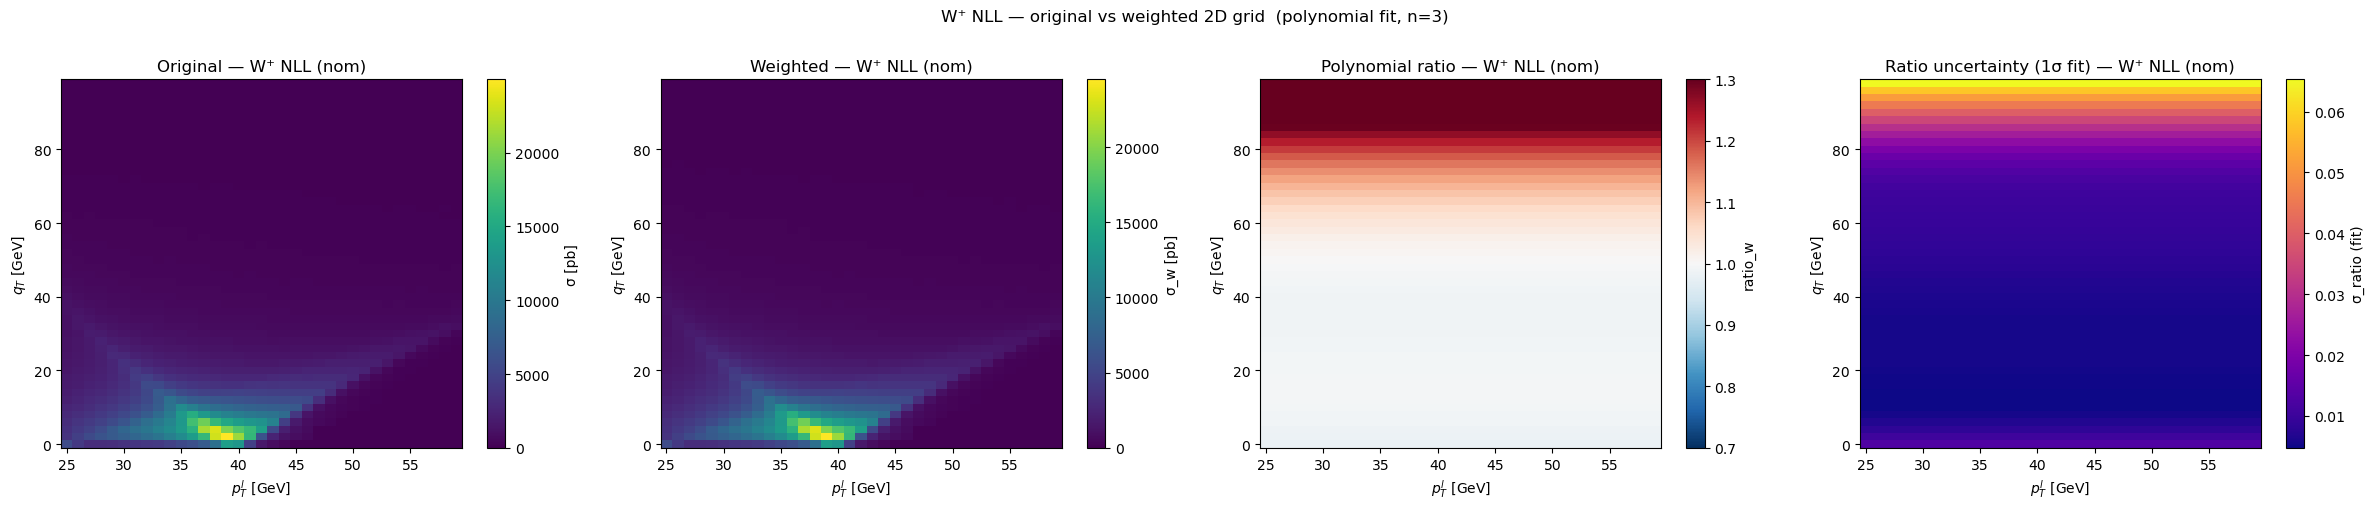

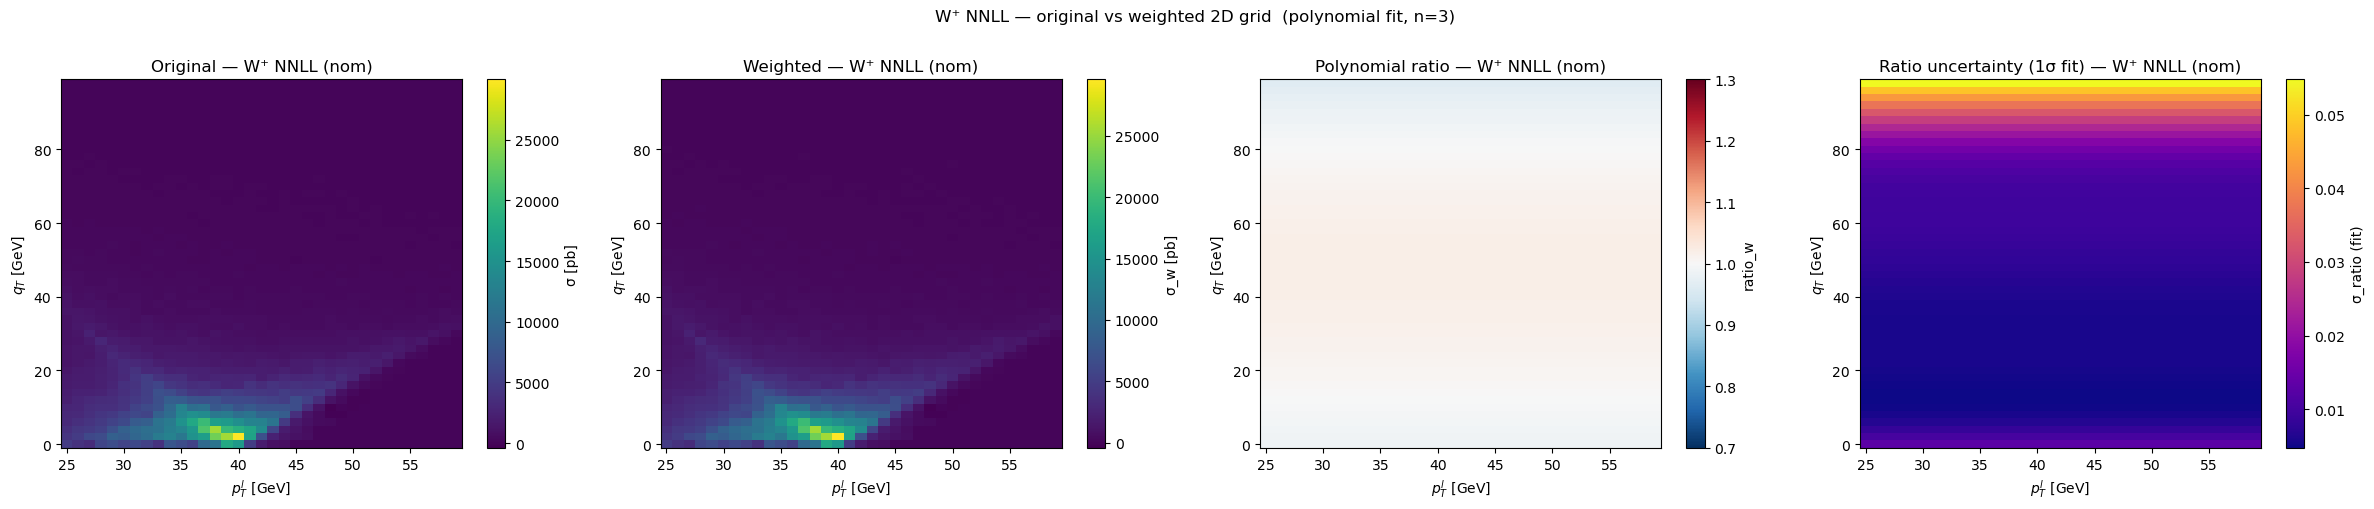

In [44]:
# ── visual comparison: original vs weighted (nominal, one order at a time) ─────
for ORDER in ['NLL', 'NNLL']:
    nom_q = f"order=='{ORDER}' and muR==1.0 and muF==1.0 and muQ==1.0"

    sub  = df2d_wp_weighted.query(nom_q)
    orig = sub.pivot_table(index='qt_lo', columns='ptl_lo', values='value')
    weig = sub.pivot_table(index='qt_lo', columns='ptl_lo', values='value_w')
    rat  = sub.pivot_table(index='qt_lo', columns='ptl_lo', values='ratio_w')
    srat = sub.pivot_table(index='qt_lo', columns='ptl_lo', values='sigma_ratio_w')

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    kw = dict(shading='auto')

    im0 = axes[0].pcolormesh(orig.columns, orig.index, orig.values, cmap='viridis', **kw)
    plt.colorbar(im0, ax=axes[0], label='σ [pb]')
    axes[0].set_title(f'Original — W⁺ {ORDER} (nom)')

    im1 = axes[1].pcolormesh(weig.columns, weig.index, weig.values, cmap='viridis', **kw)
    plt.colorbar(im1, ax=axes[1], label='σ_w [pb]')
    axes[1].set_title(f'Weighted — W⁺ {ORDER} (nom)')

    im2 = axes[2].pcolormesh(rat.columns, rat.index, rat.values,
                              cmap='RdBu_r', vmin=0.7, vmax=1.3, **kw)
    plt.colorbar(im2, ax=axes[2], label='ratio_w')
    axes[2].set_title(f'Polynomial ratio — W⁺ {ORDER} (nom)')

    im3 = axes[3].pcolormesh(srat.columns, srat.index, srat.values,
                              cmap='plasma', **kw)
    plt.colorbar(im3, ax=axes[3], label='σ_ratio (fit)')
    axes[3].set_title(f'Ratio uncertainty (1σ fit) — W⁺ {ORDER} (nom)')

    for ax in axes:
        ax.set_xlabel(r'$p_T^l$ [GeV]')
        ax.set_ylabel(r'$q_T$ [GeV]')

    plt.suptitle(f'W⁺ {ORDER} — original vs weighted 2D grid  (polynomial fit, n={POLY_DEG})',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


## 13 — Distribution in $p_T^l$: weighted sum vs proj_ptl

For each $p_T^l$ bin, the $q_T$ bins of the **weighted** 2D grid are summed
(errors in quadrature). The result is compared to the precomputed
projection `proj_ptl`.

- **Upper panel**: $p_T^l$ distribution — weighted sum vs `proj_ptl`
- **Lower panel**: ratio (weighted sum) / proj_ptl

/var/folders/ry/sd5pd0bs35j5pf2hschhct4c0000gn/T/ipykernel_71076/888416145.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


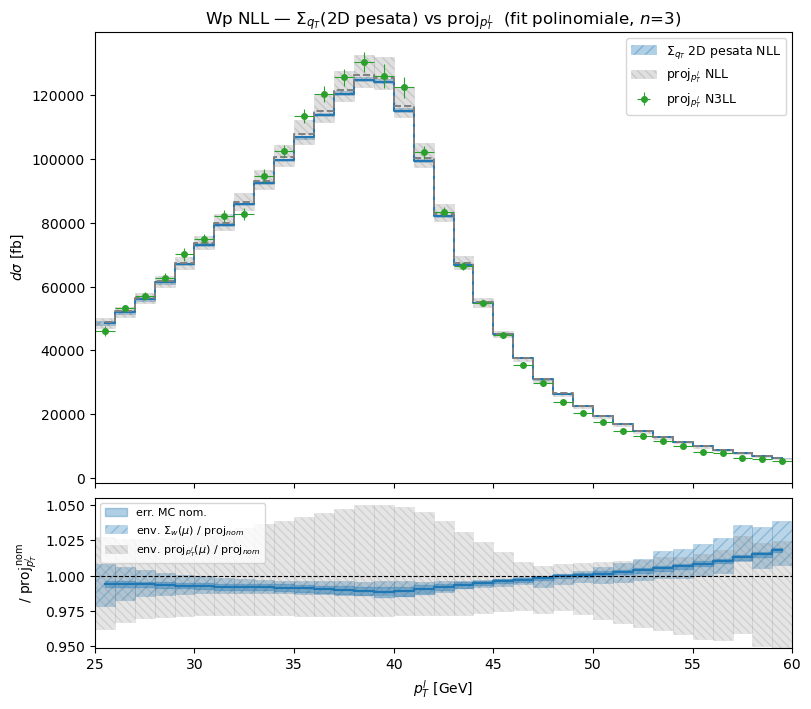

/var/folders/ry/sd5pd0bs35j5pf2hschhct4c0000gn/T/ipykernel_71076/888416145.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


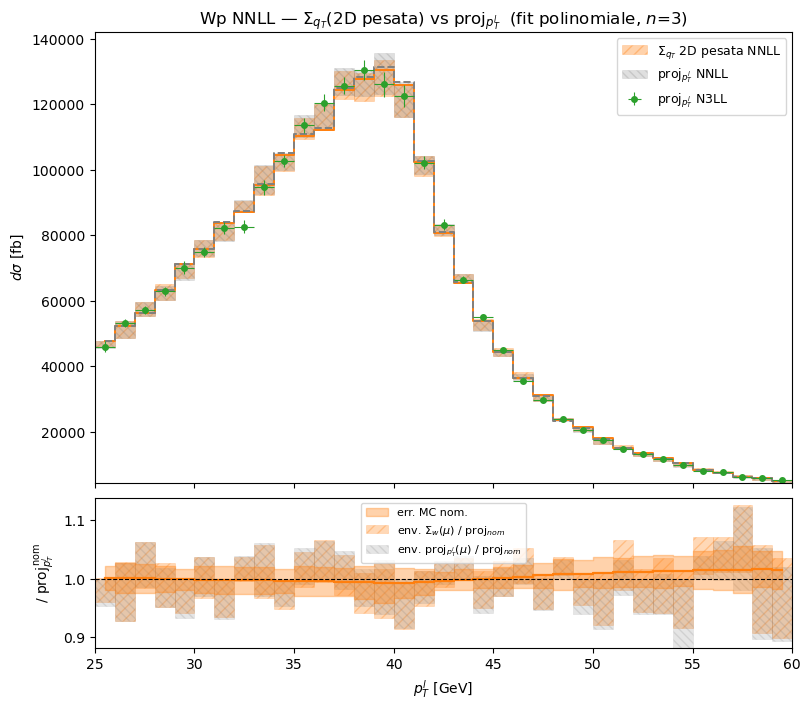

In [40]:
BOSON    = 'Wp'
nom_base = "muF==1.0 and muQ==1.0 and muR==1.0"

# ── N3LL proj_ptl (upper panel only) ─────────────────────────────────────────
pptl_n3ll = (df_pptl.query(f"boson=='{BOSON}' and order=='N3LL' and {nom_base}")
             .set_index('ptl_lo').sort_index())

for ORDER, color in [('NLL', 'C0'), ('NNLL', 'C1')]:
    nom_q = f"order=='{ORDER}' and {nom_base}"

    # ── weighted sum over q_T (nominal) ────────────────────────────────────────
    nom_w = df2d_wp_weighted.query(nom_q)
    sum_w = (nom_w.groupby('ptl_lo').agg(value_w=('value_w', 'sum'), error_w=('error_w', lambda x: np.sqrt((x**2).sum()))).sort_index())

    # ── nominal proj_ptl (current order) ──────────────────────────────────────
    pptl_nom = (df_pptl.query(f"boson=='{BOSON}' and {nom_q}")
                .set_index('ptl_lo').sort_index())

    common = sorted(set(sum_w.index) & set(pptl_nom.index) & set(pptl_n3ll.index))
    ptl_c  = pptl_nom.loc[common, 'ptl_center'].values
    w_arr  = (pptl_nom.loc[common, 'ptl_hi'] - np.array(common)).values

    vw,  ew  = sum_w.loc[common,     'value_w'].values, sum_w.loc[common,     'error_w'].values
    vp,  ep  = pptl_nom.loc[common,  'value'].values,  pptl_nom.loc[common,  'error'].values
    vn3, en3 = pptl_n3ll.loc[common, 'value'].values,  pptl_n3ll.loc[common, 'error'].values

    # ── nominal ratio / proj_ptl_nom ───────────────────────────────────────────
    ratio     = vw / vp
    ratio_err = ew / vp

    # ── scale envelope: weighted sum ───────────────────────────────────────────
    g_w  = (df2d_wp_weighted[df2d_wp_weighted.order == ORDER]
            .groupby(['muR', 'muF', 'muQ', 'ptl_lo'])['value_w'].sum()
            .reset_index().groupby('ptl_lo')['value_w'])
    up_w = g_w.max().reindex(common).values
    lo_w = g_w.min().reindex(common).values

    # ── scale envelope: proj_ptl ───────────────────────────────────────────────
    up_p, lo_p = envelope(df_pptl, BOSON, ORDER, x_col='ptl_lo')
    up_p = up_p.reindex(common).values
    lo_p = lo_p.reindex(common).values

    # ── envelope sum_w(μ) / proj_ptl_nom ─────────────────────────────────────
    vp_series = pd.Series(vp, index=common)
    g_w2 = (df2d_wp_weighted[df2d_wp_weighted.order == ORDER]
            .groupby(['muR', 'muF', 'muQ', 'ptl_lo'])['value_w'].sum()
            .reset_index())
    g_w2['r'] = g_w2['value_w'] / g_w2['ptl_lo'].map(vp_series)
    g_rat = g_w2[g_w2['ptl_lo'].isin(common)].groupby('ptl_lo')['r']
    up_r  = g_rat.max().reindex(common).values
    lo_r  = g_rat.min().reindex(common).values

    # ── envelope proj_ptl(μ) / proj_ptl_nom ──────────────────────────────────
    proj_env_up = up_p / vp
    proj_env_lo = lo_p / vp

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # upper panel — scale bands
    ax1.bar(np.array(common), up_w - lo_w, bottom=lo_w,
            width=w_arr, align='edge', alpha=0.35, color=color,
            hatch='///', edgecolor=color, linewidth=0.4,
            label=rf'$\Sigma_{{q_T}}$ 2D weighted {ORDER}')
    ax1.bar(np.array(common), up_p - lo_p, bottom=lo_p,
            width=w_arr, align='edge', alpha=0.25, color='gray',
            hatch='\\\\\\\\', edgecolor='gray', linewidth=0.4,
            label=f'proj$_{{p_T^l}}$ {ORDER}')
    ax1.step(ptl_c, vw, where='mid', color=color,  linewidth=1.4)
    ax1.step(ptl_c, vp, where='mid', color='gray', linewidth=1.4, linestyle='--')
    ax1.errorbar(ptl_c, vn3, yerr=en3, xerr=w_arr/2,
                 fmt='o', markersize=4, color='C2', linewidth=0,
                 elinewidth=0.8, capsize=0, label='proj$_{p_T^l}$ N3LL')

    # ratio panel — envelope sum_w(μ)/proj_ptl_nom
    ax2.bar(np.array(common), up_r - lo_r, bottom=lo_r,
            width=w_arr, align='edge', alpha=0.30, color=color,
            hatch='///', edgecolor=color, linewidth=0.4,
            label=rf'env. $\Sigma_w(\mu)$ / proj$_{{nom}}$')

    # ratio panel — envelope proj_ptl(μ)/proj_ptl_nom
    ax2.bar(np.array(common), proj_env_up - proj_env_lo, bottom=proj_env_lo,
            width=w_arr, align='edge', alpha=0.20, color='gray',
            hatch='\\\\\\\\', edgecolor='gray', linewidth=0.4,
            label='env. proj$_{p_T^l}(\mu)$ / proj$_{nom}$')

    # ratio panel — nominal with MC error
    ax2.step(ptl_c, ratio, where='mid', color=color, linewidth=1.6)
    ax2.fill_between(ptl_c, ratio - ratio_err, ratio + ratio_err,
                     step='mid', alpha=0.35, color=color, label='err. MC nom.')

    ax1.set_ylabel(r'$d\sigma$ [fb]')
    ax1.legend(fontsize=9)
    ax1.set_title(
        f'{BOSON} {ORDER} — $\\Sigma_{{q_T}}$(2D weighted) vs proj$_{{p_T^l}}$'
        f'  (polynomial fit, $n$={POLY_DEG})'
    )
    ax2.axhline(1, color='k', linewidth=0.8, linestyle='--')
    ax2.legend(fontsize=8, loc='best')
    ax2.set_xlabel(r'$p_T^l$ [GeV]')
    ax2.set_ylabel(r'/ proj$_{p_T^l}^{\,\mathrm{nom}}$')
    ax2.set_xlim(25, 60)
    plt.tight_layout()
    plt.show()
